# **1. Imports, Initialization**

In [ ]:
%pip install Groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 7.9 MB/s eta 0:00:00


In [ ]:
%pip install nest_asyncio

In [ ]:
%pip install jedi>=0.16

In [ ]:
!pip install -q -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 15.0 MB/s eta 0:00:00


In [ ]:
%pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.0/833.0 kB 22.2 MB/s eta 0:00:00


In [ ]:
!pip install networkx pydantic python-dotenv tenacity

In [ ]:
# !pip install llama-parse llama-index-core (Didn't use Llama-Parse in the end since it was 50$)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import re
import json
import random
import numpy as np
import torch
import nest_asyncio
nest_asyncio.apply()

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
from huggingface_hub import login
from google.colab import userdata
from groq import Groq
#from llama_parse import LlamaParse
import anthropic

login(token=userdata.get('HF_TOKEN'))
client = Groq(api_key=userdata.get('your_groq_key'))
client_anth = anthropic.Anthropic(api_key=userdata.get('your_anthropic_key'))
#os.environ["LLAMA_CLOUD_API_KEY"] = userdata.get('your_llama_key')


In [ ]:
from tenacity import retry, stop_after_attempt, wait_exponential

# Quick sanity check
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": "say: online"}],
    max_tokens=10,
)
print(response.choices[0].message.content)

Online


# **PoC - Groq Run to Assess Pipeline**

## **2.1 Parsing**

In [ ]:
PDF_PATH = "/content/drive/MyDrive/SISSA_Thesis_fin_promise.pdf"

Claude generated summaries from HierarchicalRAG are being used as placeholders

In [ ]:
with open("/content/drive/MyDrive/content_summaries_claude.json", "r") as f:
    summaries = json.load(f)

# Inspect
print(f"Total pages: {len(summaries)}")
print(f"Keys look like: {list(summaries.keys())[:5]}")
print(f"\nExample page:")
print(f"Key: {list(summaries.keys())[40]}")
print(f"Value: {list(summaries.values())[38]}")

Total pages: 289
Keys look like: ['39', '40', '41', '42', '43']

Example page:
Key: 79
Value: Type IIB string theory's nonperturbative SL(2,Z) duality, generated by S and T matrices, manifests in N=4 Hanany-Witten brane configurations through the S-duality transformation (gs → 1/gs) that exchanges NS5↔D5 branes while leaving D3-branes invariant, thereby swapping vector and hypermultiplet sectors, exchanging SU(2)_C ↔ SU(2)_H R-symmetry factors, and inducing N=4 3d mirror symmetry that maps Higgs-branch operators to Coulomb-branch monopole operators as an infrared duality exchanging flavor and topological symmetries.


In [ ]:
# Chapter page ranges (PDF page numbers matching your corpus)
CHAPTER_RANGES = {
    "ch1_background":  (39,  81),
    "ch2_unitary":     (82,  138),
    "ch3_rg_unitary":  (139, 192),
    "ch4_symplectic":  (193, 250),
    "ch5_nonsusy":     (251, 298),
    "ch6_conclusion":  (299, 308),
    "appendix_a":      (309, 314),
    "appendix_b":      (314, 328),
}

def get_chapter_summaries(summaries: dict, start: int, end: int) -> dict:
    """Extract summaries for a given page range."""
    return {
        k: v for k, v in summaries.items()
        if start <= int(k) <= end
    }

# Test
ch2 = get_chapter_summaries(summaries, 82, 138)
print(f"Ch.2 pages: {len(ch2)}")
print(f"First page: {list(ch2.keys())[0]}")
print(f"Preview: {list(ch2.values())[-1]}")

Ch.2 pages: 57
First page: 82
Preview: The thesis demonstrates that N = 2 three-dimensional chiral-planar mirror dualities can be systematically constructed by applying real mass deformations to known N = 4 Lagrangian mirror pairs, suggesting that planar Abelian dual descriptions exist for a broad class of N = 2 quiver gauge theories beyond what the authors formally prove.


## **2.2 Schema Extraction**

In [ ]:
SCHEMA_PROMPT = """
You extract graph nodes and edges from prose summaries of a physics PhD thesis on 3d N=2 mirror symmetry.

Return ONLY valid JSON, no explanation, no markdown fences.
If nothing extractable is present return all empty lists.

NODE TYPES:
- Theory: {id, name, gauge_group, rank, cs_level, matter_content: {fundamentals, anti_fundamentals}, supersymmetry, s_confines, chapter_introduced, equation_ref, notes}
- Quiver: {id, name, gauge_nodes: [{node_id, gauge_group, cs_level, flavor_attached}], supersymmetry, quiver_type, equation_ref, notes}
- Operator: {id, name, type, spin, theory_id, dressing, equation_ref, notes}

EDGE TYPES:
- mirror_of: {id, source, target, duality_type, algorithm_derived, evidence}
- abelian_dual_of: {id, source, target, algorithm_steps, evidence}
- operator_map: {id, source_operator_id, target_operator_id, mirror_pair_id, map_type, evidence}
- rg_flows_to: {id, source, target, deformation_type, deformation_parameter, change_in_F, dual_deformation, evidence}
- symmetry_map: {id, mirror_pair_id, source_symmetry, target_symmetry, direction, ir_enhancement}

EXTRACTION RULES FOR PROSE SUMMARIES:
1. Input is prose summaries, not raw paper text. Extract what is explicitly named even if details are incomplete — use null for missing fields.
2. If a summary mentions a mirror pair (e.g. "U(N)_k with F fundamentals is mirror to a planar quiver"), extract both theories/quivers and a mirror_of edge.
3. If a summary mentions an RG flow or mass deformation leading to a new theory, extract both theories and an rg_flows_to edge.
4. If a summary mentions operator maps (baryons map to monopoles), extract operator nodes and operator_map edges only if specific operator names are given. If only generic mention, skip operators but note it in the mirror_of edge evidence field.
5. A Theory is a SINGLE gauge group. Multiple gauge nodes = Quiver.
6. USp/U Sp/Usp all normalise to USp.
7. cs_level: use specific value if stated (e.g. "1/2"), use null if only a formula is given.
8. rank: SU(N) has rank N-1, USp(2N) has rank N, U(N) has rank N. The rank must be a string or integer, never a mathematical expression.
U(2N) has rank "2N", USp(2N) has rank "N", U(N) has rank "N".
9. supersymmetry: "N=4", "N=2", or "none".
10. duality_type: "N=4-mirror", "N=2-planar-Abelian", "N=2-Aharony-like", or "non-susy-planar-Abelian".
11. algorithm_derived: true if algorithm mentioned, false if only partition function evidence, null if unknown.
12. IDs are snake_case. Use gauge group + cs level + matter content e.g. "u_n_k_f_fund", "usp_4_1_7fund".
13. chapter_introduced: infer from page numbers in the input (pp.82-138 = ch2, pp.139-192 = ch3, pp.193-250 = ch4, pp.251-298 = ch5).
14. Do NOT invent operator indices. Only extract operators if specific names like M_{-000/000} or B_{1,2} appear in the summary.
15. If a field is unknown use null.

OUTPUT STRUCTURE:
{
  "theories": [...],
  "quivers": [...],
  "operators": [...],
  "mirror_edges": [...],
  "operator_maps": [...],
  "rg_flows": [...],
  "abelian_duals": [...],
  "symmetry_maps": [...]
}
"""

In [ ]:
@retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=2, min=4, max=30))
def extract_graph(text: str) -> dict:
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": SCHEMA_PROMPT},
            {"role": "user", "content": f"""The following are prose summaries of pages from a physics PhD thesis on 3d N=2 mirror symmetry. Extract all named theories, quivers, operators, and relationships you can identify. If nothing extractable return empty lists.\n\n{text}"""}
        ],
        max_tokens=8000,
        temperature=0.0,
    )

    raw = response.choices[0].message.content.strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    raw = raw.strip()

    # Fix invalid JSON expressions like 2 * "N" -> "2N"
    raw = re.sub(r'(\d+)\s*\*\s*"([^"]+)"', r'"\1\2"', raw)
    # Fix null * "N" type expressions
    raw = re.sub(r'(\w+)\s*\*\s*"([^"]+)"', r'"\1\2"', raw)

    return json.loads(raw)

In [ ]:
import time
from datetime import datetime

def chunk_chapter(chapter_summaries: dict, chunk_size: int = 10) -> list[list]:
    """
    Group pages into chunks of chunk_size.
    Each chunk = list of (page_num, summary) tuples.
    """
    pages = sorted(chapter_summaries.items(), key=lambda x: int(x[0]))
    chunks = [pages[i:i+chunk_size] for i in range(0, len(pages), chunk_size)]
    return chunks

def extract_chapter(chapter_name: str, chapter_summaries: dict,
                    save_dir: str = "/content/drive/MyDrive/graphrag_extractions") -> dict:
    """
    Extract nodes and edges from one chapter.
    Saves incrementally after each chunk.
    Returns merged extraction dict.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Check if already extracted
    save_path = f"{save_dir}/{chapter_name}.json"
    if os.path.exists(save_path):
        print(f"{chapter_name} already extracted, loading from disk.")
        with open(save_path, "r") as f:
            return json.load(f)

    chunks = chunk_chapter(chapter_summaries)
    print(f"\n=== {chapter_name}: {len(chapter_summaries)} pages, {len(chunks)} chunks ===")

    # Accumulator
    merged = {
        "theories": [], "quivers": [], "operators": [],
        "mirror_edges": [], "operator_maps": [], "rg_flows": [],
        "abelian_duals": [], "symmetry_maps": []
    }

    for i, chunk in enumerate(chunks):
        print(f"  Chunk {i+1}/{len(chunks)} (pages {chunk[0][0]}-{chunk[-1][0]})")

        # Format chunk as text
        chunk_text = "\n\n".join([
            f"[Page {page}]\n{summary}"
            for page, summary in chunk
        ])

        try:
            extracted = extract_graph(chunk_text)

            # Merge into accumulator
            for key in merged:
                merged[key].extend(extracted.get(key, []))

            print(f"    → theories: {len(extracted.get('theories',[]))}, "
                  f"mirror_edges: {len(extracted.get('mirror_edges',[]))}, "
                  f"rg_flows: {len(extracted.get('rg_flows',[]))}")

            # Rate limit buffer
            time.sleep(2)

        except Exception as e:
            print(f"    Chunk {i+1} failed: {e}")
            continue

    # Save chapter extraction
    with open(save_path, "w") as f:
        json.dump(merged, f, indent=2)
    print(f"  Saved to {save_path}")

    return merged

In [ ]:
HALLUCINATION_MARKERS = [
    "I don't see",
    "I cannot",
    "no passage",
    "you've only provided",
    "please provide",
    "no text provided",
    "only provided what appears",
]

def filter_summaries(summaries: dict) -> dict:
    filtered = {}
    skipped = 0
    for page, text in summaries.items():
        if any(marker.lower() in text.lower() for marker in HALLUCINATION_MARKERS):
            skipped += 1
            continue
        filtered[page] = text
    print(f"Filtered {skipped} hallucinated pages, {len(filtered)} remaining")
    return filtered

summaries_clean = filter_summaries(summaries)

Filtered 9 hallucinated pages, 280 remaining


In [ ]:
def patch_missing_chunk(pages: list, chapter_name: str,
                        save_dir: str = "/content/drive/MyDrive/graphrag_extractions"):
    save_path = f"{save_dir}/{chapter_name}.json"

    # Load existing
    with open(save_path, "r") as f:
        existing = json.load(f)

    # Build chunk text from specific pages
    chunk_text = "\n\n".join([
        f"[Page {page}]\n{summaries_clean[str(page)]}"
        for page in pages
        if str(page) in summaries_clean
    ])

    print(f"Patching {len(pages)} pages into {chapter_name}...")
    new_extracted = extract_graph(chunk_text)

    # Merge
    for key in existing:
        existing[key].extend(new_extracted.get(key, []))

    # Save
    with open(save_path, "w") as f:
        json.dump(existing, f, indent=2)

    print(f"Done. New counts:")
    for key, val in existing.items():
        print(f"  {key}: {len(val)}")


*Chapter-wise Extraction* (Had to be done in parts/patches since Groq would time out)

In [ ]:
ch1 = get_chapter_summaries(summaries, 39, 81)
print(f"Ch.1 pages: {len(ch1)}")
print(f"Preview p.39: {ch1['39'][:200]}")

Ch.1 pages: 43
Preview p.39: This chapter reviews how three-dimensional N=4 supersymmetric gauge theories can be geometrically engineered using D-branes in string theory, particularly through the Hanany-Witten construction, where


In [ ]:
ch1_extracted = extract_chapter("ch1_background", ch1)


=== ch1_background: 43 pages, 5 chunks ===
  Chunk 1/5 (pages 39-48)
    → theories: 2, mirror_edges: 0, rg_flows: 1
  Chunk 2/5 (pages 49-58)
    → theories: 4, mirror_edges: 0, rg_flows: 0
  Chunk 3/5 (pages 59-68)
    → theories: 0, mirror_edges: 0, rg_flows: 0
  Chunk 4/5 (pages 69-78)
    → theories: 2, mirror_edges: 1, rg_flows: 0
  Chunk 5/5 (pages 79-81)
    → theories: 1, mirror_edges: 1, rg_flows: 0
  Saved to /content/drive/MyDrive/graphrag_extractions/ch1_background.json


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions/ch1_background.json", "r") as f:
    ch1_data = json.load(f)

for key, val in ch1_data.items():
    print(f"{key}: {len(val)}")

theories: 9
quivers: 1
operators: 5
mirror_edges: 2
operator_maps: 2
rg_flows: 1
abelian_duals: 0
symmetry_maps: 1


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions/ch1_background.json", "r") as f:
    ch1_data = json.load(f)

for key, val in ch1_data.items():
    print(f"{key}: {len(val)}")

print("\n=== THEORIES ===")
for t in ch1_data["theories"]:
    print(t.get("name"), "|", t.get("supersymmetry"))

theories: 9
quivers: 1
operators: 5
mirror_edges: 2
operator_maps: 2
rg_flows: 1
abelian_duals: 0
symmetry_maps: 1

=== THEORIES ===
3d U(1) gauge theory | N=4
3d N=4 U(N) gauge theory | N=4
3d U(1) Chern-Simons gauge theory | N=2
3d U(1) gauge theory with Nf massless Dirac fermions | N=2
3d U(N) Chern-Simons gauge theory | N=2
U(3) SQCD3 with [6,2] chiral multiplets | N=2
U(N) with F fundamentals | N=4
Mirror of U(N) with F fundamentals | N=4
U(N) SQCD | N=4


In [ ]:
ch2 = get_chapter_summaries(summaries, 82, 138)
print(f"Ch.2 pages: {len(ch2)}")
ch2_extracted = extract_chapter("ch2_unitary", ch2)

Ch.2 pages: 57

=== ch2_unitary: 57 pages, 6 chunks ===
  Chunk 1/6 (pages 82-91)
    → theories: 2, mirror_edges: 2, rg_flows: 0
  Chunk 2/6 (pages 92-101)
    → theories: 3, mirror_edges: 3, rg_flows: 1
  Chunk 3/6 (pages 102-111)
    → theories: 3, mirror_edges: 2, rg_flows: 1
  Chunk 4/6 (pages 112-121)
    → theories: 3, mirror_edges: 2, rg_flows: 1
  Chunk 5/6 (pages 122-131)
    → theories: 2, mirror_edges: 1, rg_flows: 0
  Chunk 6/6 (pages 132-138)
    → theories: 3, mirror_edges: 2, rg_flows: 0
  Saved to /content/drive/MyDrive/graphrag_extractions/ch2_unitary.json


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions/ch2_unitary.json", "r") as f:
    ch2_data = json.load(f)

for key, val in ch2_data.items():
    print(f"{key}: {len(val)}")

theories: 16
quivers: 9
operators: 7
mirror_edges: 12
operator_maps: 4
rg_flows: 3
abelian_duals: 1
symmetry_maps: 0


In [ ]:
# Sanity Check

print(json.dumps(ch2_data["theories"][0], indent=2))

for t in ch2_data["theories"]:
    print(t.get("name"), "|", t.get("cs_level"), "|", t.get("matter_content"))

for e in ch2_data["mirror_edges"]:
    print(f"{e.get('source')} --> {e.get('target')} | {e.get('duality_type')}")

{
  "id": "u_n_k_f_fund",
  "name": "U(N) SQCD",
  "gauge_group": "U(N)",
  "rank": null,
  "cs_level": "-F/2+N,-F/2",
  "matter_content": {
    "fundamentals": "F",
    "anti_fundamentals": null
  },
  "supersymmetry": "N=2",
  "s_confines": null,
  "chapter_introduced": 2,
  "equation_ref": null,
  "notes": null
}
U(N) SQCD | -F/2+N,-F/2 | {'fundamentals': 'F', 'anti_fundamentals': None}
U(N) SQCD N=4 | None | {'fundamentals': 'F', 'anti_fundamentals': None}
U(N) SQCD with F fundamentals | -F/2 + N | {'fundamentals': 'F', 'anti_fundamentals': None}
SU(N) SQCD | -F²+N | {'fundamentals': 'F', 'anti_fundamentals': None}
FT[U(N)] SCFT | None | None
FT[U(N)] | None | {'fundamentals': None, 'anti_fundamentals': None}
G[U(N)] | None | {'fundamentals': None, 'anti_fundamentals': None}
N=2 SQCD | None | {'fundamentals': None, 'anti_fundamentals': None}
U(N)k with F fundamentals | None | {'fundamentals': 'F', 'anti_fundamentals': None}
S-wall | None | None
G theory | None | None
U(N) SQCD | (-

In [ ]:
ch3 = get_chapter_summaries(summaries_clean, 139, 192)
ch3_extracted = extract_chapter("ch3_rg_unitary", ch3)

with open("/content/drive/MyDrive/graphrag_extractions/ch3_rg_unitary.json", "r") as f:
    ch3_data = json.load(f)

for key, val in ch3_data.items():
    print(f"{key}: {len(val)}")


=== ch3_rg_unitary: 54 pages, 6 chunks ===
  Chunk 1/6 (pages 139-148)
    → theories: 4, mirror_edges: 2, rg_flows: 2
  Chunk 2/6 (pages 149-158)
    → theories: 6, mirror_edges: 3, rg_flows: 1
  Chunk 3/6 (pages 159-168)
    → theories: 6, mirror_edges: 3, rg_flows: 2
  Chunk 4/6 (pages 169-178)
    Chunk 4 failed: RetryError[<Future at 0x79167b4cca70 state=finished raised JSONDecodeError>]
  Chunk 5/6 (pages 179-188)
    → theories: 5, mirror_edges: 2, rg_flows: 1
  Chunk 6/6 (pages 189-192)
    Chunk 6 failed: RetryError[<Future at 0x791677ea3740 state=finished raised RateLimitError>]
  Saved to /content/drive/MyDrive/graphrag_extractions/ch3_rg_unitary.json
theories: 21
quivers: 7
operators: 2
mirror_edges: 10
operator_maps: 1
rg_flows: 6
abelian_duals: 0
symmetry_maps: 0


In [ ]:
# Patch Ch.3 chunks 4 and 6
patch_missing_chunk(list(range(169, 179)), "ch3_rg_unitary")


Patching 10 pages into ch3_rg_unitary...
Done. New counts:
  theories: 39
  quivers: 12
  operators: 2
  mirror_edges: 14
  operator_maps: 1
  rg_flows: 10
  abelian_duals: 0
  symmetry_maps: 1
Patching 4 pages into ch3_rg_unitary...


RetryError: RetryError[<Future at 0x7d72468adcd0 state=finished raised RateLimitError>]

In [ ]:
patch_missing_chunk(list(range(189, 193)), "ch3_rg_unitary")

Patching 4 pages into ch3_rg_unitary...
Done. New counts:
  theories: 47
  quivers: 12
  operators: 2
  mirror_edges: 15
  operator_maps: 1
  rg_flows: 13
  abelian_duals: 0
  symmetry_maps: 1


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions/ch3_rg_unitary.json", "r") as f:
    ch3_data = json.load(f)

print("=== COUNTS ===")
for key, val in ch3_data.items():
    print(f"{key}: {len(val)}")

print("\n=== THEORIES ===")
for t in ch3_data["theories"]:
    print(t.get("name"), "|", t.get("cs_level"))

print("\n=== RG FLOWS ===")
for e in ch3_data["rg_flows"]:
    print(f"{e.get('source')} --> {e.get('target')} | {e.get('deformation_parameter')}")

=== COUNTS ===
theories: 47
quivers: 12
operators: 2
mirror_edges: 15
operator_maps: 1
rg_flows: 13
abelian_duals: 0
symmetry_maps: 1

=== THEORIES ===
U(N)_k SQCD with F fundamentals | k
U(N)_k SQCD with (F-1) fundamentals | k±1/2
U(N-1)_k SQCD with F fundamentals | k±1/2
U(Ñ)_k SQCD with F anti-fundamentals | -k
U(N)_{k} SQCD | (N-F)/2
U(N)_{0} SQCD | 0
U(N)_{k} SQCD in Zone 1 | (N-F)/2
U(N)_{k} SQCD in Zone 2 | (N-F)/2
U(3) SQCD with 7 fundamentals | 0
U(4) SQCD with 7 antifundamentals | 0
U(N)k with F fundamentals | k
U(N)-N/2 | -N/2
U(N)-N/2+1/2 | -N/2+1/2
U(3)-1/2 | -1/2
U(3)-1/2 SQCD | -1/2
U(3)-1/2,-7/2 SQCD | -1/2,-7/2
U(2)_{1/2} SQCD3 | 1/2
U(7)_{-1/2} SQCD3 | -1/2
U(2)_{-1} SQCD | -1
U(2)_{(0,-2)} | (0,-2)
U(2)_{(-1,-3)} | (-1,-3)
U(3)_{-2} | -2
U(3)_{-1} | -1
U(3)_{-5/2} | -5/2
U(3)_{-3/2} | -3/2
U(3)_{-1/2} | -1/2
U(3)_{1/2} | 1/2
U(3)_{3/2} | 3/2
U(F-N)_{-k} | -k
U(N)_{k} | k
U(3)_{-2} | -2
U(3)_{-1} | -1
U(3)_{-5/2} | -5/2
U(3)_{-3/2} | -3/2
U(3)_{-1/2} | -1/2
U(3)_{1/2}

In [ ]:
ch4 = get_chapter_summaries(summaries_clean, 193, 250)
ch4_extracted = extract_chapter("ch4_symplectic", ch4)

with open("/content/drive/MyDrive/graphrag_extractions/ch4_symplectic.json", "r") as f:
    ch4_data = json.load(f)

for key, val in ch4_data.items():
    print(f"{key}: {len(val)}")


=== ch4_symplectic: 56 pages, 6 chunks ===
  Chunk 1/6 (pages 195-204)
    Chunk 1 failed: RetryError[<Future at 0x7b4e2ec9f9e0 state=finished raised JSONDecodeError>]
  Chunk 2/6 (pages 205-214)
    → theories: 4, mirror_edges: 3, rg_flows: 1
  Chunk 3/6 (pages 215-224)
    → theories: 4, mirror_edges: 3, rg_flows: 2
  Chunk 4/6 (pages 225-234)
    → theories: 6, mirror_edges: 7, rg_flows: 3
  Chunk 5/6 (pages 235-244)
    → theories: 5, mirror_edges: 4, rg_flows: 3
  Chunk 6/6 (pages 245-250)
    → theories: 9, mirror_edges: 4, rg_flows: 3
  Saved to /content/drive/MyDrive/graphrag_extractions/ch4_symplectic.json
theories: 28
quivers: 15
operators: 5
mirror_edges: 21
operator_maps: 3
rg_flows: 12
abelian_duals: 0
symmetry_maps: 0


In [ ]:
# Patch Ch.4 chunk 1
patch_missing_chunk(list(range(195, 205)), "ch4_symplectic")

Patching 10 pages into ch4_symplectic...
Done. New counts:
  theories: 32
  quivers: 17
  operators: 8
  mirror_edges: 23
  operator_maps: 4
  rg_flows: 13
  abelian_duals: 0
  symmetry_maps: 0


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions/ch4_symplectic.json", "r") as f:
    ch4_data = json.load(f)

print("=== THEORIES ===")
for t in ch4_data["theories"]:
    print(t.get("name"), "|", t.get("cs_level"))

print("\n=== RG FLOWS ===")
for e in ch4_data["rg_flows"]:
    print(f"{e.get('source')} --> {e.get('target')} | param: {e.get('deformation_parameter')}")

=== THEORIES ===
USp(2N) SQCD | None
USp(2N) Chern-Simons SQCD | 2N+2-F
U(1) gauge theory | None
USp(2) SQCD | None
USp(2N)_0 SQCD | 0
USp(2N)_k SQCD | k
USp(2N)_1 SQCD | 1
USp(2N)_{2N+2-F} SQCD | 2N+2-F
USp(2N) SQCD₃ | None
USp(2N) gauge theory with 1+2N-F bare Chern-Simons level | 1+2N-F
USp(2N) gauge theory with 2+2N-F Chern-Simons level | 2+2N-F
USp(2N)_k gauge theory | k
USp(2N) gauge theory with 2N-F index and F-2 fundamentals | 2N-F
USp(2N) gauge theory with 1+2N-F bare Chern-Simons level and F-1 fundamentals | 1+2N-F
USp(2N)_k Chern-Simons-SQCD | k
U(4)(0,−6) gauge theory | None
USp(4)0 SQCD | 0
USp(4)₋₁ SQCD | -1
USp(4)₋₂ gauge theory | -2
C₂⁶(−2) | -2
USp(4)₋₁ SQCD with 7 fundamentals | -1
USp(4)₋₄ with 4 fundamentals | -4
USp(4)₋₂ with 4 fundamentals | -2
USp(4)₋₅ with 3 fundamentals | -5
USp(4)₋₃ with 3 fundamentals | -3
USp(4)₁ with 5 fundamentals | 1
USp(4)₂ with 4 fundamentals | 2
USp(4)₋₁ with 5 antifundamentals and singlets | -1
U(2N) SQCD with F fundamentals and an an

In [ ]:
ch5 = get_chapter_summaries(summaries_clean, 251, 298)
ch5_extracted = extract_chapter("ch5_nonsusy", ch5)

with open("/content/drive/MyDrive/graphrag_extractions/ch5_nonsusy.json", "r") as f:
    ch5_data = json.load(f)

for key, val in ch5_data.items():
    print(f"{key}: {len(val)}")


=== ch5_nonsusy: 46 pages, 5 chunks ===
  Chunk 1/5 (pages 253-262)
    → theories: 3, mirror_edges: 2, rg_flows: 1
  Chunk 2/5 (pages 263-272)
    Chunk 2 failed: RetryError[<Future at 0x78c24a4afbf0 state=finished raised RateLimitError>]
  Chunk 3/5 (pages 273-282)
    Chunk 3 failed: RetryError[<Future at 0x78c24a4cc6e0 state=finished raised RateLimitError>]
  Chunk 4/5 (pages 283-292)
    Chunk 4 failed: RetryError[<Future at 0x78c24a379310 state=finished raised RateLimitError>]
  Chunk 5/5 (pages 293-298)
    → theories: 4, mirror_edges: 3, rg_flows: 0
  Saved to /content/drive/MyDrive/graphrag_extractions/ch5_nonsusy.json
theories: 7
quivers: 4
operators: 5
mirror_edges: 5
operator_maps: 4
rg_flows: 1
abelian_duals: 0
symmetry_maps: 1


In [ ]:
patch_missing_chunk(list(range(263, 272)), "ch5_nonsusy")


Patching 9 pages into ch5_nonsusy...
Done. New counts:
  theories: 9
  quivers: 4
  operators: 7
  mirror_edges: 7
  operator_maps: 5
  rg_flows: 1
  abelian_duals: 0
  symmetry_maps: 1


In [ ]:
patch_missing_chunk(list(range(273, 282)), "ch5_nonsusy")

Patching 9 pages into ch5_nonsusy...
Done. New counts:
  theories: 12
  quivers: 5
  operators: 9
  mirror_edges: 10
  operator_maps: 7
  rg_flows: 1
  abelian_duals: 0
  symmetry_maps: 1


In [ ]:
patch_missing_chunk(list(range(283, 292)), "ch5_nonsusy")

Patching 9 pages into ch5_nonsusy...
Done. New counts:
  theories: 17
  quivers: 6
  operators: 10
  mirror_edges: 11
  operator_maps: 8
  rg_flows: 4
  abelian_duals: 1
  symmetry_maps: 1


In [ ]:
patch_missing_chunk(list(range(293, 298)), "ch5_nonsusy")

Patching 5 pages into ch5_nonsusy...
Done. New counts:
  theories: 19
  quivers: 7
  operators: 13
  mirror_edges: 13
  operator_maps: 11
  rg_flows: 4
  abelian_duals: 1
  symmetry_maps: 1


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions/ch5_nonsusy.json", "r") as f:
    ch5_data = json.load(f)

print("=== COUNTS ===")
for key, val in ch5_data.items():
    print(f"{key}: {len(val)}")

print("\n=== THEORIES ===")
for t in ch5_data["theories"]:
    print(json.dumps(t, indent=2))

print("\n=== MIRROR EDGES ===")
for e in ch5_data["mirror_edges"]:
    print(json.dumps(e, indent=2))

print("\n=== RG FLOWS ===")
for e in ch5_data["rg_flows"]:
    print(json.dumps(e, indent=2))

=== COUNTS ===
theories: 19
quivers: 7
operators: 13
mirror_edges: 13
operator_maps: 11
rg_flows: 4
abelian_duals: 1
symmetry_maps: 1

=== THEORIES ===
{
  "id": "su_n_k_f_fund",
  "name": "SU(N) QCD3",
  "gauge_group": "SU(N)",
  "rank": "N-1",
  "cs_level": "2N-Ns-k",
  "matter_content": {
    "fundamentals": "Ns",
    "anti_fundamentals": null
  },
  "supersymmetry": "N=2",
  "s_confines": null,
  "chapter_introduced": 5,
  "equation_ref": null,
  "notes": null
}
{
  "id": "u_1_k_f_fund",
  "name": "U(1) QED3",
  "gauge_group": "U(1)",
  "rank": "1",
  "cs_level": "-Ns-Nf/2-k",
  "matter_content": {
    "fundamentals": "Nf",
    "anti_fundamentals": null
  },
  "supersymmetry": "none",
  "s_confines": null,
  "chapter_introduced": 5,
  "equation_ref": null,
  "notes": null
}
{
  "id": "su_2_1_5_fund",
  "name": "SU(2) QCD3",
  "gauge_group": "SU(2)",
  "rank": "1",
  "cs_level": "-1",
  "matter_content": {
    "fundamentals": "5",
    "anti_fundamentals": null
  },
  "supersymmetry"

In [ ]:
appendix_b = get_chapter_summaries(summaries_clean, 314, 328)
appendix_b_extracted = extract_chapter("appendix_b", appendix_b)

with open("/content/drive/MyDrive/graphrag_extractions/appendix_b.json", "r") as f:
    appendix_b_data = json.load(f)

for key, val in appendix_b_data.items():
    print(f"{key}: {len(val)}")


=== appendix_b: 14 pages, 2 chunks ===
  Chunk 1/2 (pages 314-323)
    Chunk 1 failed: RetryError[<Future at 0x7a59178efda0 state=finished raised RateLimitError>]
  Chunk 2/2 (pages 324-327)
    Chunk 2 failed: RetryError[<Future at 0x7a591791eb10 state=finished raised RateLimitError>]
  Saved to /content/drive/MyDrive/graphrag_extractions/appendix_b.json
theories: 0
quivers: 0
operators: 0
mirror_edges: 0
operator_maps: 0
rg_flows: 0
abelian_duals: 0
symmetry_maps: 0


In [ ]:
patch_missing_chunk(list(range(314, 323)), "appendix_b")


Patching 9 pages into appendix_b...
Done. New counts:
  theories: 5
  quivers: 5
  operators: 7
  mirror_edges: 5
  operator_maps: 3
  rg_flows: 1
  abelian_duals: 1
  symmetry_maps: 1


In [ ]:
patch_missing_chunk(list(range(324, 328)), "appendix_b")


Patching 4 pages into appendix_b...
Done. New counts:
  theories: 5
  quivers: 5
  operators: 7
  mirror_edges: 5
  operator_maps: 3
  rg_flows: 1
  abelian_duals: 1
  symmetry_maps: 1


## **2.3 Post-processing Fixes**

In [ ]:
import json
import os
import re
from pathlib import Path

EXTRACTION_DIR = "/content/drive/MyDrive/graphrag_extractions"

CHAPTER_FILES = {
    "ch1_background":  1,
    "ch2_unitary":     2,
    "ch3_rg_unitary":  3,
    "ch4_symplectic":  4,
    "ch5_nonsusy":     5,
    "appendix_b":      99,
}

def load_all_chapters(extraction_dir: str = EXTRACTION_DIR) -> dict:
    """
    Load and merge all chapter JSONs into one dict.
    Tags each node/edge with source chapter.
    """
    merged = {
        "theories": [], "quivers": [], "operators": [],
        "mirror_edges": [], "operator_maps": [], "rg_flows": [],
        "abelian_duals": [], "symmetry_maps": []
    }

    for chapter_name, chapter_num in CHAPTER_FILES.items():
        path = os.path.join(extraction_dir, f"{chapter_name}.json")
        if not os.path.exists(path):
            print(f"WARNING: {chapter_name}.json not found, skipping")
            continue

        with open(path, "r") as f:
            data = json.load(f)

        # Tag everything with source chapter
        for key in merged:
            for item in data.get(key, []):
                item["_source_chapter"] = chapter_num
                merged[key].append(item)

        print(f"Loaded {chapter_name}: "
              f"{len(data.get('theories',[]))} theories, "
              f"{len(data.get('mirror_edges',[]))} mirror edges, "
              f"{len(data.get('rg_flows',[]))} rg_flows")

    print(f"\nTotal before post-processing:")
    for key, val in merged.items():
        print(f"  {key}: {len(val)}")

    return merged

In [ ]:
load_all_chapters()

Loaded ch1_background: 9 theories, 2 mirror edges, 1 rg_flows
Loaded ch2_unitary: 16 theories, 12 mirror edges, 3 rg_flows
Loaded ch3_rg_unitary: 47 theories, 15 mirror edges, 13 rg_flows
Loaded ch4_symplectic: 32 theories, 23 mirror edges, 13 rg_flows
Loaded ch5_nonsusy: 19 theories, 13 mirror edges, 4 rg_flows
Loaded appendix_b: 5 theories, 5 mirror edges, 1 rg_flows

Total before post-processing:
  theories: 128
  quivers: 51
  operators: 42
  mirror_edges: 70
  operator_maps: 25
  rg_flows: 35
  abelian_duals: 3
  symmetry_maps: 4


{'theories': [{'id': 'u_1_0',
   'name': '3d U(1) gauge theory',
   'gauge_group': 'U(1)',
   'rank': 1,
   'cs_level': None,
   'matter_content': {'fundamentals': None, 'anti_fundamentals': None},
   'supersymmetry': 'N=4',
   's_confines': None,
   'chapter_introduced': 1,
   'equation_ref': None,
   'notes': 'topological U(1)T symmetry',
   '_source_chapter': 1},
  {'id': 'u_n_k',
   'name': '3d N=4 U(N) gauge theory',
   'gauge_group': 'U(N)',
   'rank': 'N',
   'cs_level': None,
   'matter_content': {'fundamentals': None, 'anti_fundamentals': None},
   'supersymmetry': 'N=4',
   's_confines': None,
   'chapter_introduced': 1,
   'equation_ref': None,
   'notes': 'Yang-Mills action',
   '_source_chapter': 1},
  {'id': 'u_1_k',
   'name': '3d U(1) Chern-Simons gauge theory',
   'gauge_group': 'U(1)',
   'rank': 1,
   'cs_level': None,
   'matter_content': {'fundamentals': None, 'anti_fundamentals': None},
   'supersymmetry': 'N=2',
   's_confines': None,
   'chapter_introduced': Non

In [ ]:
def deduplicate_nodes(merged):
    """
    Deduplicate Theory nodes by (gauge_group, cs_level, fundamentals).
    Keep the version with most non-null fields.
    Deduplicate Quiver nodes by id, keeping first occurrence.
    """
    def score(node):
        return sum(1 for v in node.values() if v is not None)

    # Deduplicate theories
    seen = {}
    for t in merged["theories"]:
        mc = t.get("matter_content") or {}
        key = (
            t.get("gauge_group", ""),
            str(t.get("cs_level", "")),
            str(mc.get("fundamentals", "")),
            str(t.get("supersymmetry", "")),
        )
        if key not in seen or score(t) > score(seen[key]):
            seen[key] = t

    before = len(merged["theories"])
    merged["theories"] = list(seen.values())
    print(f"deduplicate_nodes theories: {before} → {len(merged['theories'])}")

    # Deduplicate quivers by id
    seen_q = {}
    for q in merged["quivers"]:
        qid = q.get("id", "")
        if qid not in seen_q or score(q) > score(seen_q[qid]):
            seen_q[qid] = q
    before_q = len(merged["quivers"])
    merged["quivers"] = list(seen_q.values())
    print(f"deduplicate_nodes quivers: {before_q} → {len(merged['quivers'])}")

    # Deduplicate operators by (name, theory_id)
    seen_op = {}
    for op in merged["operators"]:
        key = (op.get("name", ""), op.get("theory_id", ""))
        if key not in seen_op:
            seen_op[key] = op
    before_op = len(merged["operators"])
    merged["operators"] = list(seen_op.values())
    print(f"deduplicate_nodes operators: {before_op} → {len(merged['operators'])}")

    return merged

In [ ]:
def fix_none_targets(merged):
    """Remove edges where source or target is None."""
    for key in ["mirror_edges", "rg_flows", "abelian_duals", "operator_maps"]:
        before = len(merged[key])
        if key == "operator_maps":
            merged[key] = [
                e for e in merged[key]
                if e.get("source_operator_id") and e.get("target_operator_id")
            ]
        else:
            merged[key] = [
                e for e in merged[key]
                if e.get("source") and e.get("target")
            ]
        after = len(merged[key])
        if before != after:
            print(f"fix_none_targets: removed {before-after} from {key}")
    return merged


In [ ]:
def fix_ch5_supersymmetry(merged):
    """All theories introduced in Ch.5 are non-susy."""
    count = 0
    for t in merged["theories"]:
        chapter = t.get("_source_chapter") or t.get("chapter_introduced")
        try:
            if int(str(chapter)) == 5 and t.get("supersymmetry") != "none":
                t["supersymmetry"] = "none"
                count += 1
        except:
            pass
    for q in merged["quivers"]:
        chapter = q.get("_source_chapter") or q.get("chapter_introduced")
        try:
            if int(str(chapter)) == 5 and q.get("supersymmetry") not in ("none", None):
                q["supersymmetry"] = "none"
                count += 1
        except:
            pass
    print(f"fix_ch5_supersymmetry: fixed {count} nodes")
    return merged

In [ ]:
def fix_ch5_matter_content(merged):
    """
    Split matter content strings like '5 scalars, 2 fermions'
    into fermions_Nf and scalars_Ns fields.
    """
    count = 0
    pattern = re.compile(r'(\d+)\s*scalar', re.IGNORECASE)
    fpattern = re.compile(r'(\d+)\s*fermi', re.IGNORECASE)
    for t in merged["theories"]:
        chapter = t.get("_source_chapter") or t.get("chapter_introduced")
        try:
            if int(str(chapter)) != 5:
                continue
        except:
            continue
        mc = t.get("matter_content", {}) or {}
        fund = str(mc.get("fundamentals", "") or "")
        if "scalar" in fund.lower() or "fermi" in fund.lower():
            sm = pattern.search(fund)
            fm = fpattern.search(fund)
            t["matter_content"]["scalars_Ns"] = int(sm.group(1)) if sm else None
            t["matter_content"]["fermions_Nf"] = int(fm.group(1)) if fm else None
            t["matter_content"]["fundamentals"] = None
            count += 1
    print(f"fix_ch5_matter_content: fixed {count} nodes")
    return merged

In [ ]:
def fix_chapter_introduced_types(merged):
    """Convert chapter_introduced from string to int where possible."""
    count = 0
    for key in ["theories", "quivers", "operators"]:
        for item in merged[key]:
            val = item.get("chapter_introduced")
            if isinstance(val, str):
                try:
                    item["chapter_introduced"] = int(val)
                    count += 1
                except:
                    pass
    print(f"fix_chapter_introduced_types: fixed {count} nodes")
    return merged

In [ ]:
def fix_rank_types(merged):
    """Convert rank from string to int where it's a pure integer string."""
    count = 0
    for t in merged["theories"] + merged["quivers"]:
        val = t.get("rank")
        if isinstance(val, str):
            try:
                t["rank"] = int(val)
                count += 1
            except:
                pass  # keep as string if symbolic like "N-1"
    print(f"fix_rank_types: fixed {count} nodes")
    return merged

In [ ]:
def remove_hallucinated_nodes(merged):
    """
    Remove known hallucinated/placeholder nodes and their edges.
    """
    BAD_IDS = {
        "s_wall", "g_theory", "u_nf_mirror", "u_2__1__3_mirror",
        "planar_abelian_quiver",  # too generic, conflicts with real nodes
    }
    BAD_NAMES = {
        "S-wall", "G theory", "Mirror of U(N) with F fundamentals",
        "Planar Abelian Quiver",  # generic placeholder
    }

    # Collect IDs to remove
    remove_ids = set()
    for t in merged["theories"]:
        if t.get("id") in BAD_IDS or t.get("name") in BAD_NAMES:
            remove_ids.add(t["id"])
    for q in merged["quivers"]:
        if q.get("id") in BAD_IDS or q.get("name") in BAD_NAMES:
            remove_ids.add(q["id"])

    before_t = len(merged["theories"])
    before_q = len(merged["quivers"])

    merged["theories"] = [t for t in merged["theories"] if t["id"] not in remove_ids]
    merged["quivers"] = [q for q in merged["quivers"] if q["id"] not in remove_ids]

    # Remove edges referencing removed nodes
    for key in ["mirror_edges", "rg_flows", "abelian_duals"]:
        before = len(merged[key])
        merged[key] = [
            e for e in merged[key]
            if e.get("source") not in remove_ids
            and e.get("target") not in remove_ids
        ]
        after = len(merged[key])
        if before != after:
            print(f"  removed {before-after} edges from {key}")

    print(f"remove_hallucinated_nodes: removed "
          f"{before_t - len(merged['theories'])} theories, "
          f"{before_q - len(merged['quivers'])} quivers")
    return merged

In [ ]:
def fix_duality_types(merged):
    """
    Fix non-schema duality_type values.
    'self-mirror' → flag for manual review in notes, keep edge but fix type.
    Ch.5 mirror edges → non-susy-planar-Abelian.
    """
    VALID_TYPES = {
        "N=4-mirror", "N=2-planar-Abelian",
        "N=2-Aharony-like", "non-susy-planar-Abelian"
    }
    count = 0
    for e in merged["mirror_edges"]:
        dt = e.get("duality_type", "")
        chapter = e.get("_source_chapter", 0)

        if dt not in VALID_TYPES:
            if "self" in str(dt).lower():
                # FT[U(N)] self-mirror is N=4
                e["duality_type"] = "N=4-mirror"
                e["notes"] = (e.get("notes") or "") + " [was: self-mirror]"
            else:
                e["duality_type"] = "N=2-planar-Abelian"
                e["notes"] = (e.get("notes") or "") + f" [was: {dt}]"
            count += 1

        # Ch.5 edges should be non-susy unless already correct
        if chapter == 5 and dt == "N=2-planar-Abelian":
            e["duality_type"] = "non-susy-planar-Abelian"
            count += 1

    print(f"fix_duality_types: fixed {count} edges")
    return merged

In [ ]:
def tag_ch1_reference_nodes(merged):
    """Tag Ch.1 nodes as reference_only so they don't start traversals."""
    count = 0
    for key in ["theories", "quivers"]:
        for item in merged[key]:
            if item.get("_source_chapter") == 1:
                item["reference_only"] = True
                count += 1
    print(f"tag_ch1_reference_nodes: tagged {count} nodes")
    return merged

In [ ]:
def add_confinement_conditions(merged):
    """
    Add confinement_condition string where s_confines is True
    or where we can infer it from gauge group.
    """
    count = 0
    for t in merged["theories"]:
        if t.get("confinement_condition"):
            continue
        gg = t.get("gauge_group", "")
        if "USp" in gg:
            t["confinement_condition"] = "F < 2N+2"
        elif "U(" in gg or "SU(" in gg:
            t["confinement_condition"] = "F < 2N"
        if t.get("confinement_condition"):
            count += 1
    print(f"add_confinement_conditions: added to {count} nodes")
    return merged

In [ ]:
def fix_g_u_n(merged):
    """
    G[U(N)] should be two Quiver nodes (chiral + planar)
    connected by a mirror_of edge, not one Theory node.
    """
    # Remove G[U(N)] from theories
    g_theories = [t for t in merged["theories"] if "G[U" in t.get("name", "")]
    merged["theories"] = [t for t in merged["theories"] if "G[U" not in t.get("name", "")]

    if not g_theories:
        print("fix_g_u_n: no G[U(N)] theory nodes found")
        return merged

    # Add two correct Quiver nodes
    g_chiral = {
        "id": "g_u_n_chiral",
        "name": "G[U(N)] chiral",
        "gauge_nodes": [{"node_id": f"u_{i}", "gauge_group": f"U({i})",
                         "cs_level": "1", "flavor_attached": None}
                        for i in range(1, 4)],  # U(1)×U(2)×U(3) as example
        "supersymmetry": "N=2",
        "quiver_type": "G[U(N)]",
        "equation_ref": "2.40",
        "notes": "N=2 S-wall, chiral UV completion. CS level +1 at each node.",
        "_source_chapter": 2,
        "reference_only": False,
    }
    g_planar = {
        "id": "g_u_n_planar",
        "name": "G[U(N)] planar",
        "gauge_nodes": [{"node_id": f"u_{i}", "gauge_group": f"U({i})",
                         "cs_level": "-1", "flavor_attached": None}
                        for i in range(1, 4)],
        "supersymmetry": "N=2",
        "quiver_type": "G[U(N)]",
        "equation_ref": "2.40",
        "notes": "N=2 S-wall, planar UV completion. Arrows reversed from chiral version.",
        "_source_chapter": 2,
        "reference_only": False,
    }
    merged["quivers"].extend([g_chiral, g_planar])

    # Add mirror_of edge between them
    merged["mirror_edges"].append({
        "id": "g_u_n_chiral_planar_mirror",
        "source": "g_u_n_chiral",
        "target": "g_u_n_planar",
        "duality_type": "N=2-planar-Abelian",
        "algorithm_derived": True,
        "evidence": "Eq. 2.40",
        "_source_chapter": 2,
    })

    # Update any existing edges that pointed to old g_u_n id
    for key in ["mirror_edges", "rg_flows", "abelian_duals"]:
        for e in merged[key]:
            if e.get("source") == "g_u_n":
                e["source"] = "g_u_n_chiral"
            if e.get("target") == "g_u_n":
                e["target"] = "g_u_n_chiral"

    print(f"fix_g_u_n: replaced {len(g_theories)} theory node(s) with 2 quiver nodes + 1 mirror edge")
    return merged


In [ ]:
def convert_mirror_to_abelian_dual(merged):
    """
    Mirror edges with duality_type N=2-planar-Abelian or non-susy-planar-Abelian
    where target is a Quiver → also create abelian_dual_of edge.
    """
    quiver_ids = {q["id"] for q in merged["quivers"]}
    new_duals = []
    for e in merged["mirror_edges"]:
        if e.get("duality_type") in ("N=2-planar-Abelian", "non-susy-planar-Abelian"):
            if e.get("target") in quiver_ids:
                new_duals.append({
                    "id": f"abelian_dual_{e['id']}",
                    "source": e["source"],
                    "target": e["target"],
                    "algorithm_steps": None,
                    "evidence": e.get("evidence"),
                    "_source_chapter": e.get("_source_chapter"),
                })
    before = len(merged["abelian_duals"])
    merged["abelian_duals"].extend(new_duals)
    print(f"convert_mirror_to_abelian_dual: added {len(new_duals)} edges "
          f"({before} → {len(merged['abelian_duals'])})")
    return merged

In [ ]:
def post_process(merged: dict) -> dict:
    print("\n=== POST-PROCESSING ===\n")
    merged = fix_none_targets(merged)
    merged = fix_ch5_supersymmetry(merged)
    merged = fix_ch5_matter_content(merged)
    merged = fix_chapter_introduced_types(merged)
    merged = fix_rank_types(merged)
    merged = remove_hallucinated_nodes(merged)
    merged = deduplicate_nodes(merged)
    merged = fix_duality_types(merged)
    merged = tag_ch1_reference_nodes(merged)
    #merged = add_confinement_conditions(merged)
    merged = fix_g_u_n(merged)
    merged = convert_mirror_to_abelian_dual(merged)

    print("\n=== FINAL COUNTS ===")
    for key, val in merged.items():
        print(f"  {key}: {len(val)}")
    return merged

### 2.3.1 Pydantic Validation

In [ ]:
from pydantic import BaseModel, field_validator
from typing import Optional, Union

class MatterContent(BaseModel):
    fundamentals: Optional[Union[int, str]] = None
    anti_fundamentals: Optional[Union[int, str]] = None
    fermions_Nf: Optional[Union[int, str]] = None
    scalars_Ns: Optional[Union[int, str]] = None

class Theory(BaseModel):
    id: str
    name: str
    gauge_group: Optional[str] = None
    rank: Optional[Union[int, str]] = None
    cs_level: Optional[str] = None
    matter_content: Optional[MatterContent] = None
    supersymmetry: Optional[str] = None
    s_confines: Optional[bool] = None
    confinement_condition: Optional[str] = None
    chapter_introduced: Optional[int] = None
    equation_ref: Optional[str] = None
    notes: Optional[str] = None
    reference_only: Optional[bool] = False

class QuiverNode(BaseModel):
    node_id: Optional[str] = None
    gauge_group: Optional[str] = None
    cs_level: Optional[str] = None
    flavor_attached: Optional[Union[int, str]] = None

class Quiver(BaseModel):
    id: str
    name: str
    gauge_nodes: Optional[list] = None
    supersymmetry: Optional[str] = None
    quiver_type: Optional[str] = None
    chapter_introduced: Optional[int] = None
    equation_ref: Optional[str] = None
    notes: Optional[str] = None
    reference_only: Optional[bool] = False

class Operator(BaseModel):
    id: str
    name: str
    type: Optional[str] = None
    spin: Optional[str] = None  # keep as string
    theory_id: Optional[str] = None
    dressing: Optional[str] = None
    chapter_introduced: Optional[int] = None
    equation_ref: Optional[str] = None
    notes: Optional[str] = None

    @field_validator('spin', mode='before')
    @classmethod
    def coerce_spin(cls, v):
        if v is None:
            return None
        return str(v)  # converts int 0 → "0"

class MirrorEdge(BaseModel):
    id: str
    source: str
    target: str
    duality_type: Optional[str] = None
    algorithm_derived: Optional[bool] = None
    evidence: Optional[str] = None
    notes: Optional[str] = None

class OperatorMap(BaseModel):
    id: str
    source_operator_id: str
    target_operator_id: str
    mirror_pair_id: Optional[str] = None
    map_type: Optional[str] = None
    evidence: Optional[str] = None

class RGFlow(BaseModel):
    id: str
    source: str
    target: str
    deformation_type: Optional[str] = None
    deformation_parameter: Optional[str] = None
    change_in_F: Optional[Union[int, str]] = None
    change_in_rank: Optional[int] = None
    change_in_cs_level: Optional[str] = None
    dual_deformation: Optional[str] = None
    evidence: Optional[str] = None

class AbelianDual(BaseModel):
    id: str
    source: str
    target: str
    algorithm_steps: Optional[str] = None
    evidence: Optional[str] = None

class SymmetryMap(BaseModel):
    id: str
    mirror_pair_id: Optional[str] = None
    source_symmetry: Optional[str] = None
    target_symmetry: Optional[str] = None
    direction: Optional[str] = None
    ir_enhancement: Optional[str] = None

    @field_validator('ir_enhancement', mode='before')
    @classmethod
    def coerce_ir(cls, v):
        if v is None:
            return None
        return str(v)  # converts bool True → "True"


def validate_all(processed: dict) -> tuple:
    model_map = {
        "theories": Theory,
        "quivers": Quiver,
        "operators": Operator,
        "mirror_edges": MirrorEdge,
        "operator_maps": OperatorMap,
        "rg_flows": RGFlow,
        "abelian_duals": AbelianDual,
        "symmetry_maps": SymmetryMap,
    }
    valid = {k: [] for k in processed}
    invalid = {k: [] for k in processed}

    for key, Model in model_map.items():
        for item in processed.get(key, []):
            try:
                # Convert cs_level to string if needed
                if "cs_level" in item and item["cs_level"] is not None:
                    item["cs_level"] = str(item["cs_level"])
                valid[key].append(Model(**item))
            except Exception as e:
                invalid[key].append({"item": item, "error": str(e)})

    print("\n=== VALIDATION ===")
    for key in valid:
        print(f"  {key}: {len(valid[key])} valid, {len(invalid[key])} invalid")
        for bad in invalid[key][:3]:  # show first 3 errors only
            print(f"    ERROR: {bad['error']}")

    return valid, invalid

### 2.3.2 NetworkX Construction

In [ ]:
import networkx as nx

def edge_attrs(d, extra={}):
    """Remove 'id' to avoid NetworkX conflict, merge extra attrs."""
    attrs = {k: v for k, v in d.items() if k != "id"}
    attrs.update({k: v for k, v in extra.items() if k != "id"})
    attrs["edge_id"] = d.get("id")  # preserve id as edge_id
    return attrs

def build_graph(valid: dict) -> nx.MultiDiGraph:
    G = nx.MultiDiGraph()

    # Build symmetry map lookup
    sym_lookup = {}
    for s in valid.get("symmetry_maps", []):
        d = s.model_dump() if hasattr(s, 'model_dump') else s
        sym_lookup[d.get("mirror_pair_id", "")] = d

    # Add Theory nodes
    for t in valid["theories"]:
        d = t.model_dump() if hasattr(t, 'model_dump') else t
        G.add_node(d["id"], node_type="Theory", **d)

    # Add Quiver nodes
    for q in valid["quivers"]:
        d = q.model_dump() if hasattr(q, 'model_dump') else q
        G.add_node(d["id"], node_type="Quiver", **d)

    # Add Operator nodes
    for op in valid["operators"]:
        d = op.model_dump() if hasattr(op, 'model_dump') else op
        G.add_node(d["id"], node_type="Operator", **d)

    # Add mirror_of edges (with symmetry map data merged in)
    for e in valid["mirror_edges"]:
        d = e.model_dump() if hasattr(e, 'model_dump') else e
        sym = sym_lookup.get(d["id"], {})
        G.add_edge(d["source"], d["target"],
           edge_type="mirror_of", **edge_attrs(d, sym))
        G.add_edge(d["target"], d["source"],
           edge_type="mirror_of", **edge_attrs(d, sym))

    # Add abelian_dual_of edges
    for e in valid["abelian_duals"]:
        d = e.model_dump() if hasattr(e, 'model_dump') else d
        G.add_edge(d["source"], d["target"],
           edge_type="abelian_dual_of", **edge_attrs(d, sym))

    # Add operator_map edges
    for e in valid["operator_maps"]:
        d = e.model_dump() if hasattr(e, 'model_dump') else e
        G.add_edge(d["source_operator_id"], d["target_operator_id"],
           edge_type="operator_map", **edge_attrs(d, sym))

    # Add rg_flows_to edges
    for e in valid["rg_flows"]:
        d = e.model_dump() if hasattr(e, 'model_dump') else e
        G.add_edge(d["source"], d["target"],
           edge_type="rg_flows_to", **edge_attrs(d, sym))

    # Summary
    node_types = {}
    edge_types = {}
    for _, data in G.nodes(data=True):
        t = data.get("node_type", "?")
        node_types[t] = node_types.get(t, 0) + 1
    for _, _, data in G.edges(data=True):
        t = data.get("edge_type", "?")
        edge_types[t] = edge_types.get(t, 0) + 1

    print(f"\n=== GRAPH BUILT ===")
    print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
    print(f"Node types: {node_types}")
    print(f"Edge types: {edge_types}")

    return G

*Save Everything(!!)*

In [ ]:
def save_processed(processed: dict,
                   path="/content/drive/MyDrive/graphrag_extractions/processed_graph.json"):
    with open(path, "w") as f:
        json.dump(processed, f, indent=2, default=str)
    print(f"Saved processed graph to {path}")


def save_graph(G: nx.MultiDiGraph,
               path="/content/drive/MyDrive/graphrag_extractions/graph.graphml"):
    # GraphML can't handle None values — convert to empty string
    for _, data in G.nodes(data=True):
        for k, v in list(data.items()):
            if v is None:
                data[k] = ""
            elif isinstance(v, dict):
                data[k] = json.dumps(v, default=str)
            elif isinstance(v, list):
                data[k] = json.dumps(v, default=str)

    for _, _, data in G.edges(data=True):
        for k, v in list(data.items()):
            if v is None:
                data[k] = ""
            elif isinstance(v, dict):
                data[k] = json.dumps(v, default=str)
            elif isinstance(v, list):
                data[k] = json.dumps(v, default=str)

    nx.write_graphml(G, path)
    print(f"Saved GraphML to {path}")

save_graph(G)


Saved GraphML to /content/drive/MyDrive/graphrag_extractions/graph.graphml


In [ ]:
# Step 1: Load
merged = load_all_chapters()

# Step 2: Post-process
processed = post_process(merged)

# Step 3: Save processed JSON
save_processed(processed)

# Step 4: Validate
valid, invalid = validate_all(processed)

# Step 5: Build graph
G = build_graph(valid)

# Step 6: Save graph
save_graph(G)

Loaded ch1_background: 9 theories, 2 mirror edges, 1 rg_flows
Loaded ch2_unitary: 16 theories, 12 mirror edges, 3 rg_flows
Loaded ch3_rg_unitary: 47 theories, 15 mirror edges, 13 rg_flows
Loaded ch4_symplectic: 32 theories, 23 mirror edges, 13 rg_flows
Loaded ch5_nonsusy: 19 theories, 13 mirror edges, 4 rg_flows
Loaded appendix_b: 5 theories, 5 mirror edges, 1 rg_flows

Total before post-processing:
  theories: 128
  quivers: 51
  operators: 42
  mirror_edges: 70
  operator_maps: 25
  rg_flows: 35
  abelian_duals: 3
  symmetry_maps: 4

=== POST-PROCESSING ===

fix_none_targets: removed 6 from mirror_edges
fix_none_targets: removed 4 from rg_flows
fix_none_targets: removed 15 from operator_maps
fix_ch5_supersymmetry: fixed 22 nodes
fix_ch5_matter_content: fixed 7 nodes
fix_chapter_introduced_types: fixed 8 nodes
fix_rank_types: fixed 39 nodes
  removed 8 edges from mirror_edges
  removed 1 edges from rg_flows
remove_hallucinated_nodes: removed 5 theories, 2 quivers
deduplicate_nodes the

In [ ]:
json_path = "/content/drive/MyDrive/graphrag_extractions/graph.json"
data = nx.node_link_data(G)
with open(json_path, "w") as f:
    json.dump(data, f, indent=2, default=str)
print(f"Saved JSON to {json_path}")

Saved JSON to /content/drive/MyDrive/graphrag_extractions/graph.json


In [ ]:
phantoms = [(n, d) for n, d in G.nodes(data=True)
            if d.get("node_type") == "?"]
print(f"Phantom nodes: {len(phantoms)}")
for n, d in phantoms[:5]:
    print(f"  {n}")
    in_edges = list(G.in_edges(n, data=True))
    print(f"  in_edges: {[(u, d.get('edge_type')) for u,v,d in in_edges]}")

Phantom nodes: 0


<Figure size 1400x900 with 0 Axes>

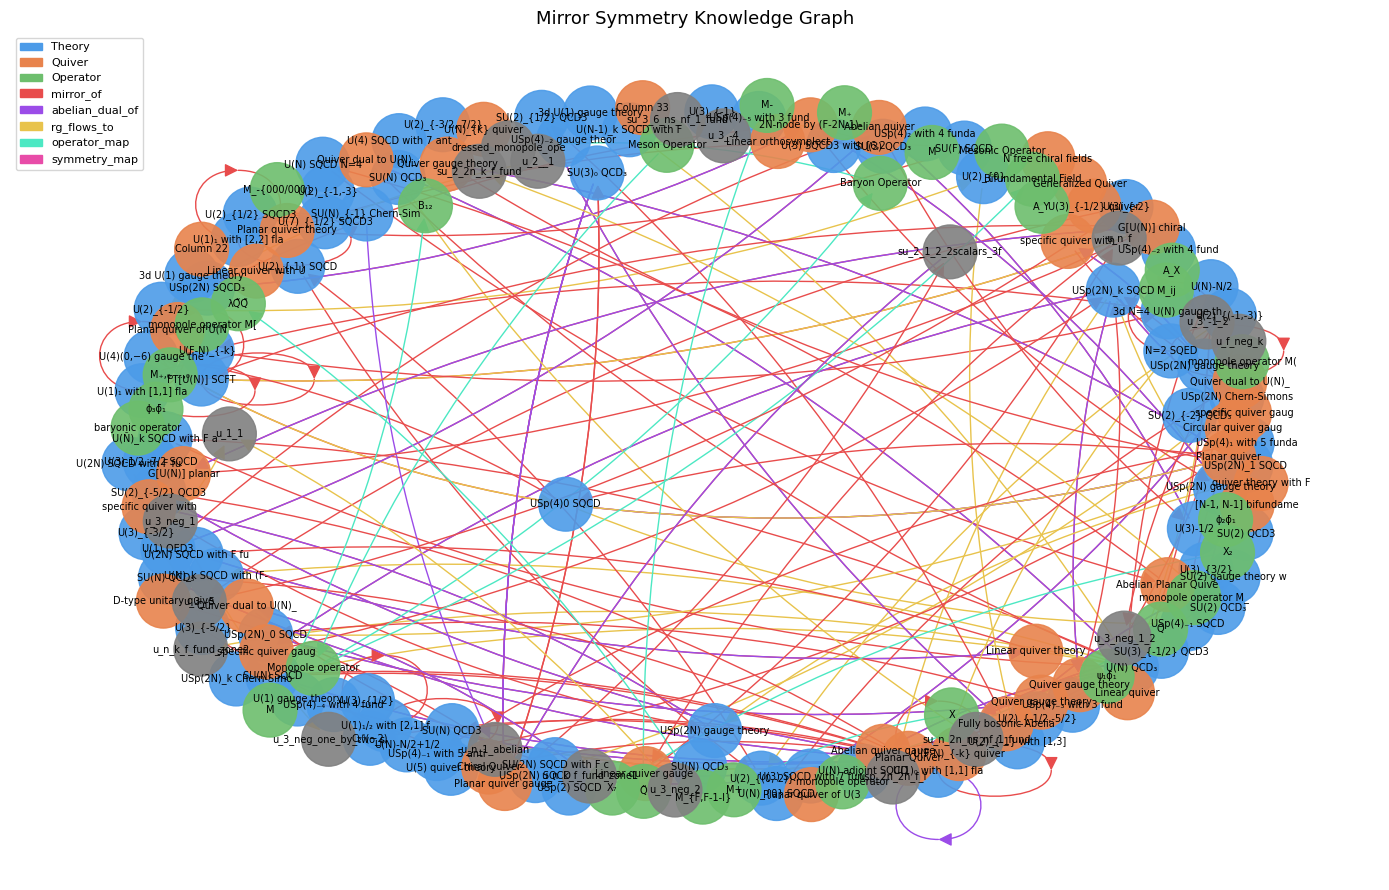

In [ ]:
import matplotlib.pyplot as plt

def visualise_graph(G: nx.MultiDiGraph, pos=None):
    plt.figure(figsize=(14, 9))

    if pos is None:
        pos = nx.spring_layout(G, seed=42, k=2)
    plt.figure(figsize=(14, 9))

    # Layout
    pos = nx.spring_layout(G, seed=42, k=2)

    # Color nodes by type
    color_map = {"Theory": "#4C9BE8", "Quiver": "#E8834C", "Operator": "#6DBE6D"}
    node_colors = [color_map.get(G.nodes[n].get("node_type", "?"), "grey") for n in G.nodes]

    # Color edges by type
    edge_color_map = {
        "mirror_of": "#E84C4C",
        "abelian_dual_of": "#9B4CE8",
        "rg_flows_to": "#E8C34C",
        "operator_map": "#4CE8C3",
        "symmetry_map": "#E84CA8",
    }
    edge_colors = [edge_color_map.get(d.get("edge_type", "?"), "grey")
                   for _, _, d in G.edges(data=True)]

    # Draw
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500, alpha=0.9)
    nx.draw_networkx_labels(G, pos,
                            labels={n: G.nodes[n].get("name", n)[:20] for n in G.nodes},
                            font_size=7)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors,
                           arrows=True, arrowsize=20,
                           connectionstyle="arc3,rad=0.1")

    # Legend
    from matplotlib.patches import Patch, FancyArrow
    node_legend = [Patch(color=c, label=t) for t, c in color_map.items()]
    edge_legend = [Patch(color=c, label=t) for t, c in edge_color_map.items()]
    plt.legend(handles=node_legend + edge_legend, loc="upper left", fontsize=8)

    plt.title("Mirror Symmetry Knowledge Graph", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
visualise_graph(G)

## **2.4 Multi-Hop Spot Checks**

In [ ]:
def fuzzy_name_match(query_fragment: str, node_name: str) -> bool:
    """Match if all significant words in fragment appear in node name."""
    # Normalise both
    q = query_fragment.lower().replace("_", " ").replace("{", "").replace("}", "")
    n = node_name.lower().replace("_", " ").replace("{", "").replace("}", "")

    # Split query into tokens, check all appear in node name
    tokens = [t for t in q.split() if len(t) > 1]  # skip single chars
    return all(t in n for t in tokens)


def multi_hop_query(G, start_name: str, edge_sequence: list[str]) -> list[dict]:
    """
    Traverse the graph following a sequence of edge types.

    Example: edge_sequence=["rg_flows_to", "mirror_of"] answers:
    "what is the mirror of the mass deformation of X?"
    """

    # Step 1: find the starting node by name fragment
    start_nodes = [
        n for n, d in G.nodes(data=True)
        if fuzzy_name_match(start_name, d.get("name", ""))
        and d.get("node_type") == start_node_type
    ]

    if not start_nodes:
        print(f"No {start_node_type} node found matching '{start_name}'")
        return []

    print(f"Starting from: {[G.nodes[n]['name'] for n in start_nodes]}")

    # Step 2: traverse edge by edge
    # frontier = list of (current_node_id, path_so_far)
    frontier = [(n, []) for n in start_nodes]

    for step, edge_type in enumerate(edge_sequence):
        next_frontier = []
        for node_id, path in frontier:
            # look at all outgoing edges from this node
            for _, target, data in G.out_edges(node_id, data=True):
                if data.get("edge_type") == edge_type:
                    next_frontier.append((
                        target,
                        path + [{
                            "from": G.nodes[node_id].get("name", node_id),
                            "edge": edge_type,
                            "to": G.nodes[target].get("name", target),
                            "evidence": data.get("evidence"),
                        }]
                    ))

        frontier = next_frontier
        if not frontier:
            print(f"Dead end at step {step+1} — no '{edge_type}' edges from current nodes")
            return []

    # Step 3: collect results
    results = []
    for node_id, path in frontier:
        node_data = dict(G.nodes[node_id])
        results.append({
            "answer_node": node_data.get("name", node_id),
            "node_type": node_data.get("node_type"),
            "path": path,
            "node_data": node_data,
        })

    return results

In [ ]:
# Query 1: "what is the mirror of SU(2) with 5 fundamentals?"
r1 = multi_hop_query(G, "U(2)_{1/2}", ["mirror_of"])
for r in r1:
    print(f"Answer: {r['answer_node']}")
    for hop in r['path']:
        print(f"  {hop['from']} --[{hop['edge']}]--> {hop['to']} (evidence: {hop['evidence']})")

print("---")


Starting from: ['U(2)_{1/2} SQCD3', 'SU(2)_{1/2} QCD3']
Answer: U(7)_{-1/2} SQCD3
  U(2)_{1/2} SQCD3 --[mirror_of]--> U(7)_{-1/2} SQCD3 (evidence: Aharony duality and planar Abelian dualities)
Answer: Fully bosonic Abelian quiver gauge theory
  SU(2)_{1/2} QCD3 --[mirror_of]--> Fully bosonic Abelian quiver gauge theory (evidence: Tables 5.9 and 5.10, Figure 5.16)
---


In [ ]:
r1 = multi_hop_query(G, "USp(4)", ["mirror_of"])
r2 = multi_hop_query(G, "USp(4)", ["rg_flows_to", "mirror_of"])
r3 = multi_hop_query(G, "U(3)", ["rg_flows_to", "rg_flows_to", "mirror_of"])

Starting from: ['USp(4)0 SQCD', 'USp(4)₋₁ SQCD', 'USp(4)₋₂ gauge theory', 'USp(4)₋₄ with 4 fundamentals', 'USp(4)₋₂ with 4 fundamentals', 'USp(4)₋₅ with 3 fundamentals', 'USp(4)₋₃ with 3 fundamentals', 'USp(4)₁ with 5 fundamentals', 'USp(4)₂ with 4 fundamentals', 'USp(4)₋₁ with 5 antifundamentals and singlets']
Starting from: ['USp(4)0 SQCD', 'USp(4)₋₁ SQCD', 'USp(4)₋₂ gauge theory', 'USp(4)₋₄ with 4 fundamentals', 'USp(4)₋₂ with 4 fundamentals', 'USp(4)₋₅ with 3 fundamentals', 'USp(4)₋₃ with 3 fundamentals', 'USp(4)₁ with 5 fundamentals', 'USp(4)₂ with 4 fundamentals', 'USp(4)₋₁ with 5 antifundamentals and singlets']
Starting from: ['U(3) SQCD3 with [6,2] chiral multiplets', 'U(3) SQCD with 7 fundamentals', 'U(3)-1/2', 'U(3)-1/2,-7/2 SQCD', 'U(3)_{-2}', 'U(3)_{-1}', 'U(3)_{-5/2}', 'U(3)_{-3/2}', 'U(3)_{1/2}', 'U(3)_{3/2}', 'SU(3)₀ QCD₃', 'SU(3)_{-1/2} QCD3', 'SU(3) QCD₃', 'U(3)_{-1/2} quiver', 'Planar quiver of U(3)_{-1/2}']
Dead end at step 2 — no 'rg_flows_to' edges from current nod

In [ ]:
for e in valid["rg_flows"]:
    d = e.model_dump()
    if "u_3" in d.get("source", "") or "U(3)" in d.get("source", ""):
        print(f"{d['source']} --> {d['target']} | {d.get('deformation_parameter')}")

u_3_neg_one_by_two_neg_seven_by_two_sqcd --> u_3_neg_one_by_two_sqcd | None
u_3_-1_2 --> u_3_-2 | ±m
u_3_-5_2 --> u_3_-3_2 | ±m
u_3_neg_2 --> u_1_1 | None
u_3_neg_1 --> u_1_1 | None
su_3_6_ns_nf_fund --> su_3_6_ns_nf_1_fund | Negative mass-squared


In [ ]:
for e in valid["rg_flows"]:
    d = e.model_dump()
    if "usp" in d.get("source", "").lower():
        print(f"{d['source']} --> {d['target']} | {d.get('deformation_parameter')}")

usp_2n_f --> usp_2n_f_n2 | None
usp_2n_0_f --> usp_2n_1_f | None
usp_2n_k_f --> usp_2n_2n_f_f | None
usp_2n_k_f --> usp_2n_2_2n_f | m
usp_2n_2_2n_f --> usp_2n_2_2n_f_1 | -m
usp_2n_2_2n_f --> quiver_2n_f_2n_5 | 2Nth-m
usp_4_0 --> usp_4_neg1 | None
usp_4_0 --> planar_quiver_2 | None


# **Redux: Full GraphRAG Pipeline**

## **3.1 Parsing and Extraction with Gemini-3.1 Flash Lite**




In [ ]:
PDF_PATH = "/content/drive/MyDrive/SISSA_Thesis_fin_promise.pdf"

In [ ]:
!pip install google-genai

from google import genai
from google.colab import userdata

In [ ]:
GEMINI_API_KEY = userdata.get('gemini_api_key')
client = genai.Client(api_key=GEMINI_API_KEY)

# Sanity check
response = client.models.generate_content(
    model='gemini-3.1-flash-lite',
    contents='say: online'
)
print(response.text)

online


In [ ]:
import pathlib

with open(PDF_PATH, 'rb') as f:
    pdf_bytes = f.read()



response = client.models.generate_content(
    model='gemini-3.1-flash-lite',
    contents=[
        {
            "parts": [
                {
                    "inline_data": {
                        "mime_type": "application/pdf",
                        "data": pdf_bytes
                    }
                },
                {
                    "text": "What is on page 86 of this document? Describe any figures or equations you see."
                }
            ]
        }
    ]
)
print(response.text)

Based on the provided document, here is a description of the content on page 86:

**Header:** The page contains the header "The ABCD’s of Mirror Symmetry" at the top.

**Content:**
The page is entirely occupied by **Figure 2.1**, which is titled "Schematic depiction of the $\mathcal{N} = 2$ mirror duality...". The figure provides a visual representation of a duality between two theories:

*   **The Top Row (The Parent Theory):**
    *   **Left side:** A schematic representation of $\mathcal{N} = 4$ $U(N)$ SQCD with $F$ flavors. It shows a circle labeled "$N$" (the gauge group) and a square labeled "$F$" (the flavor symmetry group). It includes a label "$\mathcal{W} = \mathcal{W}_{\mathcal{N}=4}$".
    *   **Right side:** An arrow labeled "$\iff$" points to the mirror theory, represented as a linear quiver diagram with multiple gauge nodes (circles) and flavor nodes (squares). It also includes a label "$\mathcal{W} = \mathcal{W}_{\mathcal{N}=4}$".
*   **The Transformation (The Deformati

In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 26.2 MB/s eta 0:00:00


In [ ]:
import fitz

PDF_PATH = "/content/drive/MyDrive/SISSA_Thesis_fin_promise.pdf"
SPLIT_DIR = "/content/drive/MyDrive/thesis_split_chapter"
os.makedirs(SPLIT_DIR, exist_ok=True)

# Page ranges (0-indexed for PyMuPDF, so subtract 1)
CHAPTER_RANGES = {
    "ch2_unitary":    (82, 137),
    "ch3_rg_unitary": (138, 191),
    "ch4_symplectic": (194, 249),
    "ch5_nonsusy":    (252, 297),
    "appendix_b":     (314, 327),
}

def split_chapters(pdf_path, output_dir, ranges):
    doc = fitz.open(pdf_path)
    for chapter_name, (start, end) in ranges.items():
        out_path = f"{output_dir}/{chapter_name}.pdf"
        if os.path.exists(out_path):
            print(f"{chapter_name} already split, skipping")
            continue
        new_doc = fitz.open()
        new_doc.insert_pdf(doc, from_page=start, to_page=end)
        new_doc.save(out_path)
        print(f"Saved {chapter_name}: pages {start+1}-{end+1} ({end-start+1} pages)")
    doc.close()

split_chapters(PDF_PATH, SPLIT_DIR, CHAPTER_RANGES)

Saved ch2_unitary: pages 83-138 (56 pages)
Saved ch3_rg_unitary: pages 139-192 (54 pages)
Saved ch4_symplectic: pages 195-250 (56 pages)
Saved ch5_nonsusy: pages 253-298 (46 pages)
Saved appendix_b: pages 315-328 (14 pages)


## **3.2 Schema Extraction**

In [ ]:
CLAUDE_EXTRACTION_PROMPT = """You are extracting a physics knowledge graph from pages of a PhD thesis titled "The ABCD's of Mirror Symmetry" by Anant Shri (SISSA, 2026). The thesis studies 3d N≤2 mirror symmetry for unitary and symplectic CS-matter theories.

Return ONLY valid JSON matching the output structure exactly. No explanation, no markdown fences.
If a page contains no extractable graph data, return all empty lists.

═══════════════════════════════════════
PHYSICS CONTEXT (read carefully)
═══════════════════════════════════════

GAUGE GROUP NOTATION:
- U(N)_{k,k+ℓN}: unitary group rank N, CS level pair. ALWAYS preserve both components as string "(k, k+ℓN)". ℓ=-1 for the main family so cs_level = "(k, k-N)". If only one component is given "(k)", ℓ=0 and cs_level = "(k)"
- USp(2N)_k: symplectic group rank N, single CS level k.
- SU(N)_k: special unitary, rank N-1.
- Ranks: U(N)→N, SU(N)→N-1, USp(2N)→N.
- C_N in Dynkin notation = USp(2N). Always extract as USp(2N), never as C_N.
- B_N = SO(2N+1), D_N = SO(2N) — extract as SO groups if they appear.

CS LEVEL SHIFTS FROM MASS DEFORMATIONS:
- Each massive fundamental or anti-fundamental chiral: contributes (-1/2, -1/2) to (k, k+ℓN)
- Massive adjoint chiral: contributes (+N, 0)
- So ±m on one fundamental: change_in_cs_level = "±1/2" on both components
- USp(2N): ±m on one fundamental shifts k by ±1

ZONE STRUCTURE (Ch.3, U(N) theories):
- Zone 1: F ≥ 2|k| + 2N — all 4 deformations (±m, ±mH) available
- Zone 2: 2N-F ≥ 2|k| > 0 — 3 deformations available (one mH missing)
- Zones 3/4: F < N — only ±m available
- SUSY breaks: F < 2|k| - 2N for U(N); F < 2N+2-|k| for USp(2N)

DEFORMATION TYPES:
- ±m (real-mass-fundamental): gives mass to one fundamental, no rank change. change_in_F=-1.
- ±mH (Higgsing): gives mass + Higgs gauge group. change_in_rank=-1, change_in_F=-1.
- USp theories: ONLY ±m available (no mH). One deformation acts from left of quiver, other from right.

DUAL DEFORMATION RULE:
- ±m on electric side → FI parameter shift on adjacent column(s) of mirror quiver → mirror loses one node from left or right column
- +mH on electric side → mirror gauge node removed (rank reduction on mirror)
- For USp: -m acts from left of mirror quiver, +m from right (or vice versa)

S-CONFINEMENT:
- U(N)_k with F fundamentals: s-confines when F/2 + |k| = N (Zones 3,4) OR F - N (elsewhere). Terminal theory = free chiral or U(1)_1 TQFT.
- USp(2N)_k with F fundamentals: s-confines when F < 2N+2 AND 2N+2-F=|k|. Terminal = empty theory / TQFT.
- Large |k| can prevent confinement even within threshold.
- Set s_confines=true and confinement_condition accordingly.

BUILDING BLOCKS:
- FT[U(N)]: self-mirror N=4 SCFT. quiver_type="FT[U(N)]". UV = U(1)×U(2)×...×U(N-1) linear quiver.
- G[U(N)] chiral: N=2 S-wall, chiral UV completion. CS level +1 each node.
- G[U(N)] planar: N=2 S-wall, planar UV completion. Mirror of G[U(N)] chiral.
- Both are Quiver nodes, NOT Theory nodes.

ALGORITHM VOCABULARY (for algorithm_steps field):
S-move, S⁻¹-move, fusion-to-identity (chiral/planar), Higgsing, integrating-out-massive-fields, tail-contraction

NON-SUSY (Ch.5, pp.217-261):
- All theories: supersymmetry = "none"
- Matter fields: "Nf fundamental fermions" → fermions_Nf=Nf, fundamentals=null.
  "Ns fundamental scalars" → scalars_Ns=Ns, fundamentals=null.
  Never put fermionic or scalar flavors in the fundamentals field.
- Scalar mass deformations ↔ fermionic mass deformations (opposite sign on dual side)
- duality_type = "non-susy-planar-Abelian"
- Spin labels on operators (0, 1/2, 1, 3/2) MUST be extracted, never dropped

═══════════════════════════════════════
EXTRACTION RULES
═══════════════════════════════════════

NODE RULES:
1. Theory = single gauge group only. Multiple gauge nodes = Quiver.
2. USp/U Sp/USpN all → USp(2N). Never "Usp" or "U Sp".
3. cs_level: use specific value if stated. For pairs write as string "(k, k-N)". Never write formula like "F/2-N" if the actual value is given.
4. rank: integer. SU(N)→N-1, U(N)→N, USp(2N)→N. If symbolic (rank=N), keep as string "N".
5. chapter_introduced: integer. Pages 47-101=ch2, 103-155=ch3, 159-213=ch4, 217-261=ch5.
6. T[SU(N)] and all multi-node theories → Quiver, never Theory.
7. FT[U(N)] and G[U(N)] → Quiver with quiver_type "FT[U(N)]" or "G[U(N)]".
8. Planar Abelian mirrors → Quiver with quiver_type "planar-Abelian".
9. s_confines=true when:
  - USp(2N)_k: F < 2N+2 AND 2N+2-F = |k| (s-confinement boundary)
  - U(N)_k: confinement when dual rank vanishes:
  Zones 3/4: F/2 + |k| = N
  Elsewhere: F = N
  Set confinement_condition as the specific condition met.
10. Do NOT extract background/review material as nodes (brane constructions, general formulas without specific theory instances).

EDGE RULES:
11. Every rg_flows_to edge MUST have deformation_type one of: real-mass-fundamental, real-mass-adjoint, Higgsing, FI-parameter, combined.
12. deformation_parameter: "+m", "-m", "+mH", "-mH" exactly. USp only has "+m" or "-m".
13. change_in_F: always -1 for single mass deformation. Integer.
14. change_in_cs_level: "±1/2" for ±m on fundamental. "+N" for adjoint. String.
15. dual_deformation: describe what happens to mirror quiver. e.g. "mirror loses one node from left column" or "mirror rank decreases by 1".
16. Never create edge with source or target = None. Skip edge if target unnamed.
17. mirror_of edges: duality_type must be exactly one of "N=4-mirror", "N=2-planar-Abelian", "N=2-Aharony-like", "non-susy-planar-Abelian".
18. When source is non-Abelian and target is planar Abelian quiver: create BOTH mirror_of AND abelian_dual_of edge.
19. algorithm_derived=true when duality obtained by S-move algorithm. algorithm_derived=false when only partition function evidence.

OPERATOR RULES:
20. Extract operators when GNO flux configuration is given explicitly, e.g. {-,0,0,0/0,0,0} or M^{(+,-,0,...)}. Use the flux notation
as the operator name directly. NEVER invent flux values.
21. Ch.5 operators: spin field mandatory (0, 1/2, 1, 3/2). Never null for Ch.5 operators.

ID RULES:
22. IDs are snake_case, unique. Use gauge_group+cs_level+matter: "u_n_k_f_fund", "usp_4_neg1_7fund", "planar_ab_u3_neg1_2_7fund".
23. Two theories with same gauge group but different parameters get different IDs.
24. Quiver IDs include their source theory: "planar_dual_usp4_neg1_7fund".

═══════════════════════════════════════
OUTPUT STRUCTURE
═══════════════════════════════════════

{
  "theories": [
    {
      "id": "string",
      "name": "string",
      "gauge_group": "string",
      "rank": "integer or string",
      "cs_level": "string or null",
      "matter_content": {
        "fundamentals": "integer, string, or null",
        "anti_fundamentals": "integer, string, or null",
        "adjoints": "integer or null",
        "tensor": "symmetric, antisymmetric, or null",
        "fermions_Nf": "integer, string, or null",
        "scalars_Ns": "integer, string, or null"
      },
      "supersymmetry": "N=4 | N=2 | none",
      "s_confines": "bool or null",
      "confinement_condition": "string or null",
      "chapter_introduced": "integer",
      "equation_ref": "string or null",
      "notes": "string or null"
    }
  ],
  "quivers": [
    {
      "id": "string",
      "name": "string",
      "gauge_nodes": [{"node_id": "string", "gauge_group": "string", "cs_level": "string or null", "flavor_attached": "integer, string, or null"}],
      "supersymmetry": "N=4 | N=2 | none",
      "quiver_type": "planar-Abelian | linear-unitary | circular | DF | G[U(N)] | FT[U(N)] | other",
      "chapter_introduced": "integer",
      "figure_ref": "string or null",
      "notes": "string or null"
    }
  ],
  "operators": [
    {
      "id": "string",
      "name": "string",
      "type": "monopole | dressed-monopole | meson | baryon | dressed-baryon | topological-current | other",
      "spin": "0 | 1/2 | 1 | 3/2 | null",
      "theory_id": "string",
      "dressing": "string or null",
      "chapter_introduced": "integer",
      "equation_ref": "string or null",
      "notes": "string or null"
    }
  ],
  "mirror_edges": [
    {
      "id": "string",
      "source": "Theory.id or Quiver.id",
      "target": "Theory.id or Quiver.id",
      "duality_type": "N=4-mirror | N=2-planar-Abelian | N=2-Aharony-like | non-susy-planar-Abelian",
      "algorithm_derived": "bool or null",
      "partition_function_checked": "bool or null",
      "evidence": "string or null"
    }
  ],
  "operator_maps": [
    {
      "id": "string",
      "source_operator_id": "Operator.id",
      "target_operator_id": "Operator.id",
      "mirror_pair_id": "mirror_of.id",
      "map_type": "monopole-to-meson | meson-to-monopole | baryon-to-monopole | monopole-to-baryon | topological-to-flavor | other",
      "evidence": "string or null"
    }
  ],
  "rg_flows": [
    {
      "id": "string",
      "source": "Theory.id or Quiver.id",
      "target": "Theory.id or Quiver.id",
      "deformation_type": "real-mass-fundamental | real-mass-adjoint | real-mass-bifundamental | FI-parameter | Higgsing | combined",
      "deformation_parameter": "+m | -m | +mH | -mH | string or null",
      "change_in_F": "integer or null",
      "change_in_rank": "integer or null",
      "change_in_cs_level": "string or null",
      "dual_deformation": "string or null",
      "evidence": "equation or figure reference or null"
    }
  ],
  "abelian_duals": [
    {
      "id": "string",
      "source": "Theory.id",
      "target": "Quiver.id",
      "algorithm_steps": "string or null",
      "evidence": "string or null"
    }
  ],
  "symmetry_maps": [
    {
      "id": "string",
      "mirror_pair_id": "mirror_of.id",
      "source_symmetry": "string",
      "target_symmetry": "string",
      "direction": "flavor-to-topological | topological-to-flavor | both",
      "ir_enhancement": "string or null"
    }
  ]
}
"""

In [ ]:
import time

EXTRACTION_DIR = "/content/drive/MyDrive/graphrag_extractions_gemini"
os.makedirs(EXTRACTION_DIR, exist_ok=True)

def load_pdf_bytes(pdf_path):
    with open(pdf_path, 'rb') as f:
        return f.read()

def extract_chapter_gemini(chapter_name, pdf_path, save_dir=EXTRACTION_DIR, chunk_size=15):
    save_path = f"{save_dir}/{chapter_name}.json"
    if os.path.exists(save_path):
        print(f"{chapter_name} already extracted, loading from disk.")
        with open(save_path, 'r') as f:
            return json.load(f)

    print(f"\n=== Extracting {chapter_name} ===")

    merged = {
        "theories": [], "quivers": [], "operators": [],
        "mirror_edges": [], "operator_maps": [], "rg_flows": [],
        "abelian_duals": [], "symmetry_maps": []
    }

    doc = fitz.open(pdf_path)
    total_pages = len(doc)
    doc.close()

    chunks = list(range(0, total_pages, chunk_size))
    print(f"  {total_pages} pages, {len(chunks)} chunks of ~{chunk_size} pages")

    for i, start in enumerate(chunks):
        end = min(start + chunk_size - 1, total_pages - 1)
        print(f"  Chunk {i+1}/{len(chunks)} (pages {start+1}-{end+1})")

        # Extract chunk as PDF bytes
        doc = fitz.open(pdf_path)
        chunk_doc = fitz.open()
        chunk_doc.insert_pdf(doc, from_page=start, to_page=end)
        doc.close()

        import io
        buf = io.BytesIO()
        chunk_doc.save(buf)
        chunk_bytes = buf.getvalue()
        chunk_doc.close()

        prompt = f"""You are extracting a physics knowledge graph from pages of a PhD thesis on 3d mirror symmetry.

{CLAUDE_EXTRACTION_PROMPT}

Extract ALL nodes and edges from these pages. Be exhaustive.
Return ONLY valid JSON. No explanation, no markdown fences."""

        try:
            response = client.models.generate_content(
                model='gemini-3.1-flash-lite',
                contents=[{
                    "parts": [
                        {
                            "inline_data": {
                                "mime_type": "application/pdf",
                                "data": chunk_bytes
                            }
                        },
                        {"text": prompt}
                    ]
                }],
                config={
                    "max_output_tokens": 32768,
                    "temperature": 0.0,
                }
            )

            raw = response.text.strip()
            if raw.startswith("```"):
                raw = raw.split("```")[1]
                if raw.startswith("json"):
                    raw = raw[4:]
            raw = raw.strip()

            extracted = json.loads(raw)

            for key in merged:
                merged[key].extend(extracted.get(key, []))

            print(f"    → theories: {len(extracted.get('theories',[]))}, "
                  f"mirror_edges: {len(extracted.get('mirror_edges',[]))}, "
                  f"rg_flows: {len(extracted.get('rg_flows',[]))}, "
                  f"operators: {len(extracted.get('operators',[]))}")

            time.sleep(3)  # rate limit buffer

        except Exception as e:
            print(f"    Chunk {i+1} failed: {e}")
            time.sleep(5)
            continue

    with open(save_path, 'w') as f:
        json.dump(merged, f, indent=2)
    print(f"  Saved to {save_path}")

    print(f"  TOTAL: ", {k: len(v) for k, v in merged.items()})
    return merged

In [ ]:
# Sanity Check
doc = fitz.open(f"{SPLIT_DIR}/ch2_unitary.pdf")
test_doc = fitz.open()
test_doc.insert_pdf(doc, from_page=3, to_page=4)  # first 3 pages
test_path = "/content/test_ch2_p1_3.pdf"
test_doc.save(test_path)
doc.close()

test_result = extract_chapter_gemini("test_ch2_p1_3", test_path,
                                      save_dir="/content")
print(json.dumps(test_result, indent=2))


=== Extracting test_ch2_p1_3 ===
  theories: 2, mirror_edges: 2, rg_flows: 1, operators: 2
  Saved to /content/test_ch2_p1_3.json
{
  "theories": [
    {
      "id": "u_n_sqcd_f_0",
      "name": "U(N) SQCD with [F, 0] flavors",
      "gauge_group": "U(N)",
      "rank": "N",
      "cs_level": "(-F/2 + N, -F/2)",
      "matter_content": {
        "fundamentals": "F"
      },
      "supersymmetry": "N=2",
      "s_confines": null,
      "confinement_condition": null,
      "chapter_introduced": 2,
      "equation_ref": "Figure 2.1",
      "notes": "Electric theory with vanishing superpotential"
    },
    {
      "id": "u_n_sqcd_f_f",
      "name": "U(N) SQCD with [F, F] flavors",
      "gauge_group": "U(N)",
      "rank": "N",
      "cs_level": null,
      "matter_content": {
        "fundamentals": "F",
        "anti_fundamentals": "F"
      },
      "supersymmetry": "N=4",
      "s_confines": null,
      "confinement_condition": null,
      "chapter_introduced": 2,
      "equation_r

5.1.1 Chapter 2 Extraction

In [ ]:
ch2_result = extract_chapter_gemini(
    "ch2_unitary",
    f"{SPLIT_DIR}/ch2_unitary.pdf"
)

print("=== COUNTS ===")
for key, val in ch2_result.items():
    print(f"  {key}: {len(val)}")


=== Extracting ch2_unitary ===
  56 pages, 4 chunks of ~15 pages
  Chunk 1/4 (pages 1-15)
    → theories: 3, mirror_edges: 3, rg_flows: 1, operators: 3
  Chunk 2/4 (pages 16-30)
    → theories: 2, mirror_edges: 2, rg_flows: 1, operators: 3
  Chunk 3/4 (pages 31-45)
    → theories: 1, mirror_edges: 1, rg_flows: 1, operators: 0
  Chunk 4/4 (pages 46-56)
    → theories: 3, mirror_edges: 2, rg_flows: 0, operators: 1
  Saved to /content/drive/MyDrive/graphrag_extractions_gemini/ch2_unitary.json
  TOTAL:  {'theories': 9, 'quivers': 13, 'operators': 7, 'mirror_edges': 8, 'operator_maps': 3, 'rg_flows': 3, 'abelian_duals': 3, 'symmetry_maps': 3}
=== COUNTS ===
  theories: 9
  quivers: 13
  operators: 7
  mirror_edges: 8
  operator_maps: 3
  rg_flows: 3
  abelian_duals: 3
  symmetry_maps: 3


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions_gemini/ch2_unitary.json") as f:
    ch2_data = json.load(f)

print("=== THEORIES ===")
for t in ch2_data["theories"]:
    print(f"  {t.get('name')} | cs={t.get('cs_level')} | susy={t.get('supersymmetry')}")

print("\n=== MIRROR EDGES ===")
for e in ch2_data["mirror_edges"]:
    print(f"  {e.get('source')} --> {e.get('target')} | {e.get('duality_type')} | alg={e.get('algorithm_derived')}")

print("\n=== RG FLOWS ===")
for e in ch2_data["rg_flows"]:
    print(f"  {e.get('source')} --> {e.get('target')} | {e.get('deformation_parameter')} | dual={e.get('dual_deformation')}")

=== THEORIES ===
  N=4 U(N) SQCD | cs=None | susy=N=4
  N=2 U(N) SQCD | cs=(-F/2+N, -F/2) | susy=N=2
  N=2 SU(N) SQCD | cs=(-F/2+N) | susy=N=2
  FT[U(N)] SCFT | cs=None | susy=N=4
  G[U(N)] SCFT | cs=None | susy=N=2
  U(N) CS-SQCD with [F1+N, F2+N] chiral multiplets | cs=(-F1+F2/2, -F1+F2/2-N) | susy=N=2
  U(N) SQCD with [F1+N, F2+N] chiral multiplets | cs=(-(F1+F2)/2, -(F1+F2)/2 - N) | susy=N=2
  U(N) SQCD with [F1+2N, F2] chiral multiplets | cs=(-(F1+F2)/2, -(F1+F2)/2 - N) | susy=N=2
  Adjoint U(N) SQCD | cs=(-F/2, -F/2) | susy=N=2

=== MIRROR EDGES ===
  u_n_sqcd_n4 --> n4_mirror_linear_quiver | N=4-mirror | alg=False
  u_n_sqcd_n2 --> planar_abelian_mirror_u_n | N=2-planar-Abelian | alg=True
  su_n_sqcd_n2 --> planar_abelian_mirror_su_n | N=2-planar-Abelian | alg=True
  ft_u_n_scft --> ft_u_n_scft | N=4-mirror | alg=False
  g_u_n_chiral_quiver --> g_u_n_planar_quiver | N=2-planar-Abelian | alg=True
  g_u_n_chiral --> g_u_n_planar | N=2-planar-Abelian | alg=True
  u_n_sqcd_f1_f2 -->

5.1.2 Chapter 3 Extraction

In [ ]:
ch3_result = extract_chapter_gemini(
    "ch3_rg_unitary",
    f"{SPLIT_DIR}/ch3_rg_unitary.pdf",
    chunk_size=10
)
print("=== COUNTS ===")
for key, val in ch3_result.items():
    print(f"  {key}: {len(val)}")


=== Extracting ch3_rg_unitary ===
  54 pages, 6 chunks of ~10 pages
  Chunk 1/6 (pages 1-10)
    → theories: 2, mirror_edges: 0, rg_flows: 4, operators: 1
  Chunk 2/6 (pages 11-20)
    → theories: 2, mirror_edges: 2, rg_flows: 2, operators: 0
  Chunk 3/6 (pages 21-30)
    → theories: 9, mirror_edges: 8, rg_flows: 2, operators: 1
  Chunk 4/6 (pages 31-40)
    → theories: 12, mirror_edges: 1, rg_flows: 3, operators: 0
  Chunk 5/6 (pages 41-50)
    → theories: 8, mirror_edges: 1, rg_flows: 2, operators: 0
  Chunk 6/6 (pages 51-54)
    → theories: 4, mirror_edges: 1, rg_flows: 2, operators: 1
  Saved to /content/drive/MyDrive/graphrag_extractions_gemini/ch3_rg_unitary.json
  TOTAL:  {'theories': 37, 'quivers': 15, 'operators': 3, 'mirror_edges': 13, 'operator_maps': 0, 'rg_flows': 15, 'abelian_duals': 2, 'symmetry_maps': 2}
=== COUNTS ===
  theories: 37
  quivers: 15
  operators: 3
  mirror_edges: 13
  operator_maps: 0
  rg_flows: 15
  abelian_duals: 2
  symmetry_maps: 2


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions_gemini/ch3_rg_unitary.json") as f:
    ch3_data = json.load(f)

print("=== THEORIES ===")
for t in ch3_data["theories"]:
    print(f"  {t.get('name')} | cs={t.get('cs_level')} | susy={t.get('supersymmetry')}")

print("\n=== MIRROR EDGES ===")
for e in ch3_data["mirror_edges"]:
    print(f"  {e.get('source')} --> {e.get('target')} | {e.get('duality_type')} | alg={e.get('algorithm_derived')}")

print("\n=== RG FLOWS ===")
for e in ch3_data["rg_flows"]:
    print(f"  {e.get('source')} --> {e.get('target')} | {e.get('deformation_parameter')} | dual={e.get('dual_deformation')}")

=== THEORIES ===
  U(N)k SQCD with F fundamentals | cs=k | susy=N=2
  U(N)k,k+Nℓ SQCD with F fundamentals | cs=(k, k+Nℓ) | susy=N=2
  U(N)_k with F fundamentals | cs=k | susy=N=2
  U(N)_0 with F fundamentals | cs=0 | susy=N=2
  U(N)_k with F fundamentals | cs=k | susy=N=2
  U(N)_{-N/2 + 1/2} with N+1 fundamentals | cs=-N/2 + 1/2 | susy=N=2
  U(N)_{-N/2} with N fundamentals | cs=-N/2 | susy=N=2
  U(N)_{-N/2} with N fundamentals | cs=-N/2 | susy=N=2
  U(N)_k with F fundamentals (Zone 1) | cs=k | susy=N=2
  U(N)_{-F/2} with F fundamentals | cs=-F/2 | susy=N=2
  N=2 U(N)_k CS-YM | cs=k | susy=N=2
  U(3)_0 with 8 fundamentals | cs=0 | susy=N=2
  U(3)_{-1/2} with 7 fundamentals | cs=-1/2 | susy=N=2
  U(3)_{(-2,-5)} with 4 fundamentals | cs=(-2,-5) | susy=N=2
  U(3)_{(-1,-4)} with 4 fundamentals | cs=(-1,-4) | susy=N=2
  U(3)_{(0,-3)} with 4 fundamentals | cs=(0,-3) | susy=N=2
  U(3)_{(1,-2)} with 4 fundamentals | cs=(1,-2) | susy=N=2
  U(3)_{(-5/2, -11/2)} with 3 fundamentals | cs=(-5/2, -11

5.1.3 Chapter 4 Extraction

In [ ]:
ch4_result = extract_chapter_gemini(
    "ch4_symplectic",
    f"{SPLIT_DIR}/ch4_symplectic.pdf",
    chunk_size=10
)

print("=== COUNTS ===")
for key, val in ch4_result.items():
    print(f"  {key}: {len(val)}")



=== Extracting ch4_symplectic ===
  56 pages, 6 chunks of ~10 pages
  Chunk 1/6 (pages 1-10)
    → theories: 3, mirror_edges: 2, rg_flows: 1, operators: 3
  Chunk 2/6 (pages 11-20)
    → theories: 4, mirror_edges: 3, rg_flows: 2, operators: 2
  Chunk 3/6 (pages 21-30)
    → theories: 4, mirror_edges: 1, rg_flows: 1, operators: 1
  Chunk 4/6 (pages 31-40)
    → theories: 3, mirror_edges: 3, rg_flows: 2, operators: 0
  Chunk 5/6 (pages 41-50)
    → theories: 4, mirror_edges: 0, rg_flows: 1, operators: 3
  Chunk 6/6 (pages 51-56)
    → theories: 16, mirror_edges: 0, rg_flows: 2, operators: 0
  Saved to /content/drive/MyDrive/graphrag_extractions_gemini/ch4_symplectic.json
  TOTAL:  {'theories': 34, 'quivers': 17, 'operators': 9, 'mirror_edges': 9, 'operator_maps': 1, 'rg_flows': 9, 'abelian_duals': 5, 'symmetry_maps': 3}
=== COUNTS ===
  theories: 34
  quivers: 17
  operators: 9
  mirror_edges: 9
  operator_maps: 1
  rg_flows: 9
  abelian_duals: 5
  symmetry_maps: 3


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions_gemini/ch4_symplectic.json") as f:
    ch4_data = json.load(f)

print("=== THEORIES ===")
for t in ch4_data["theories"]:
    print(f"  {t.get('name')} | cs={t.get('cs_level')} | susy={t.get('supersymmetry')}")

print("\n=== MIRROR EDGES ===")
for e in ch4_data["mirror_edges"]:
    print(f"  {e.get('source')} --> {e.get('target')} | {e.get('duality_type')} | alg={e.get('algorithm_derived')}")

print("\n=== RG FLOWS ===")
for e in ch4_data["rg_flows"]:
    print(f"  {e.get('source')} --> {e.get('target')} | {e.get('deformation_parameter')} | dual={e.get('dual_deformation')}")

=== THEORIES ===
  N=4 U(2N) SQCD with F hypermultiplets and rank-2 antisymmetric tensor | cs=None | susy=N=4
  N=2 U(2N) SQCD with F fundamentals and anti-chiral antisymmetric field | cs=(1-F/2+N, 1-2N-F/2) | susy=N=2
  U(2N)_(0,-3N) CS-SQCD3 with F fundamentals and rank-2 antisymmetric tensor | cs=(0, -3N) | susy=N=2
  USp(2N) SQCD | cs=0 | susy=N=4
  USp(2N) CS-SQCD3 | cs=2N+2-F | susy=N=2
  USp(2) SQCD3 | cs=0 | susy=N=4
  U(1) theory with F fundamental multiplets | cs=None | susy=N=2
  USp(2N)_0 SQCD with F fundamentals | cs=0 | susy=N=2
  USp(2N)_{-1} SQCD with F-1 fundamentals | cs=-1 | susy=N=2
  USp(2N)_k SQCD with F fundamentals | cs=k | susy=N=2
  USp(2N)_{2N+2-F} SQCD with F fundamentals | cs=2N+2-F | susy=N=2
  USp(2N) with F fundamentals | cs=None | susy=N=4
  USp(2N) with F-1 fundamentals | cs=None | susy=N=4
  USp(2N) with F-2 fundamentals | cs=None | susy=N=4
  USp(2N)_k with 1 fundamental | cs=k | susy=N=2
  USp(4)_{-1} SQCD with 7 fundamentals | cs=-1 | susy=N=2
  US

5.1.4 Chapter 5 Extraction

In [ ]:
ch5_result = extract_chapter_gemini(
    "ch5_nonsusy",
    f"{SPLIT_DIR}/ch5_nonsusy.pdf",
    chunk_size=10
)

print("=== COUNTS ===")
for key, val in ch4_result.items():
    print(f"  {key}: {len(val)}")



=== Extracting ch5_nonsusy ===
  46 pages, 5 chunks of ~10 pages
  Chunk 1/5 (pages 1-10)
    → theories: 3, mirror_edges: 2, rg_flows: 0, operators: 3
  Chunk 2/5 (pages 11-20)
    → theories: 1, mirror_edges: 1, rg_flows: 0, operators: 3
  Chunk 3/5 (pages 21-30)
    → theories: 3, mirror_edges: 3, rg_flows: 0, operators: 5
  Chunk 4/5 (pages 31-40)
    → theories: 4, mirror_edges: 1, rg_flows: 2, operators: 2
  Chunk 5/5 (pages 41-46)
    → theories: 2, mirror_edges: 2, rg_flows: 0, operators: 2
  Saved to /content/drive/MyDrive/graphrag_extractions_gemini/ch5_nonsusy.json
  TOTAL:  {'theories': 13, 'quivers': 13, 'operators': 15, 'mirror_edges': 9, 'operator_maps': 5, 'rg_flows': 2, 'abelian_duals': 6, 'symmetry_maps': 2}
=== COUNTS ===
  theories: 10
  quivers: 10
  operators: 12
  mirror_edges: 7
  operator_maps: 5
  rg_flows: 2
  abelian_duals: 4
  symmetry_maps: 1


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions_gemini/ch5_nonsusy.json") as f:
    ch5_data = json.load(f)

print("=== THEORIES ===")
for t in ch5_data["theories"]:
    print(f"  {t.get('name')} | cs={t.get('cs_level')} | susy={t.get('supersymmetry')}")

print("\n=== MIRROR EDGES ===")
for e in ch5_data["mirror_edges"]:
    print(f"  {e.get('source')} --> {e.get('target')} | {e.get('duality_type')} | alg={e.get('algorithm_derived')}")

print("\n=== RG FLOWS ===")
for e in ch5_data["rg_flows"]:
    print(f"  {e.get('source')} --> {e.get('target')} | {e.get('deformation_parameter')} | dual={e.get('dual_deformation')}")

=== THEORIES ===
  U(1) QED3 with Ns scalars and Nf fermions | cs=-Ns-Nf/2-k | susy=none
  SU(N) QCD3 with Ns scalars | cs=2N-Ns-k | susy=none
  SU(2) QCD3 with 5 scalars | cs=-1 | susy=none
  SU(2)_-2 QCD3 with 5 scalars | cs=-2 | susy=none
  SU(N) QCD3 with Ns scalars and Nf fermions | cs=2N - Ns - Nf/2 - k | susy=none
  SU(3) at level -1/2 with 6 scalars and 1 fermion | cs=-1/2 | susy=none
  SU(2) at level -5/2 with 5 scalars and 1 fermion | cs=-5/2 | susy=none
  U(N) QCD3 with Ns scalars and Nf fermions | cs=(2N-Ns-Nf/2-k, -Ns-Nf/2-k) | susy=none
  SU(2) QCD3 with F scalars | cs=(4-F) | susy=none
  SU(3) QCD3 with Ns scalars and Nf fermions | cs=(6-Ns-Nf/2) | susy=none
  SU(N)_-1 QCD | cs=-1 | susy=none
  SU(3)_0 QCD3 with 5 scalars and 2 fermions | cs=0 | susy=none
  SU(2)_1/2 QCD3 with 2 scalars and 3 fermions | cs=1/2 | susy=none

=== MIRROR EDGES ===
  u1_cs_neg_ns_nf2_k --> planar_abelian_dual_u1_ns_nf_k | non-susy-planar-Abelian | alg=False
  su_n_cs_2n_ns_k --> planar_abelia

5.1.5 Appendix B Extraction

In [ ]:
appendix_result = extract_chapter_gemini(
    "appendix_b",
    f"{SPLIT_DIR}/appendix_b.pdf",
    chunk_size=10
)

print("=== COUNTS ===")
for key, val in appendix_result.items():
    print(f"  {key}: {len(val)}")


=== Extracting appendix_b ===
  14 pages, 2 chunks of ~10 pages
  Chunk 1/2 (pages 1-10)
    → theories: 2, mirror_edges: 2, rg_flows: 0, operators: 2
  Chunk 2/2 (pages 11-14)
    → theories: 0, mirror_edges: 0, rg_flows: 0, operators: 0
  Saved to /content/drive/MyDrive/graphrag_extractions_gemini/appendix_b.json
  TOTAL:  {'theories': 2, 'quivers': 10, 'operators': 2, 'mirror_edges': 2, 'operator_maps': 0, 'rg_flows': 0, 'abelian_duals': 0, 'symmetry_maps': 1}
=== COUNTS ===
  theories: 2
  quivers: 10
  operators: 2
  mirror_edges: 2
  operator_maps: 0
  rg_flows: 0
  abelian_duals: 0
  symmetry_maps: 1


In [ ]:
with open("/content/drive/MyDrive/graphrag_extractions_gemini/appendix_b.json") as f:
    appb_data = json.load(f)

print("=== THEORIES ===")
for t in appb_data["theories"]:
    print(f"  {t.get('name')} | cs={t.get('cs_level')} | susy={t.get('supersymmetry')}")

print("=== Quivers ===")
for t in appb_data["quivers"]:
    print(f"  {t.get('name')} | cs={t.get('cs_level')} | susy={t.get('supersymmetry')}")

print("\n=== MIRROR EDGES ===")
for e in appb_data["mirror_edges"]:
    print(f"  {e.get('source')} --> {e.get('target')} | {e.get('duality_type')} | alg={e.get('algorithm_derived')}")

print("\n=== RG FLOWS ===")
for e in appb_data["rg_flows"]:
    print(f"  {e.get('source')} --> {e.get('target')} | {e.get('deformation_parameter')} | dual={e.get('dual_deformation')}")

=== THEORIES ===
  U(1)_0 with [1, 1] chiral fields | cs=0 | susy=N=2
  U(1)_{-1/2} with [1, 0] chiral fields | cs=-1/2 | susy=N=2
=== Quivers ===
  N=4 Abelian mirror pair | cs=None | susy=N=4
  N=2 fundamental mirror pair | cs=None | susy=N=2
  N=2 self-dual SQED F=2 | cs=None | susy=N=2
  Planar quiver 1 | cs=None | susy=none
  Planar quiver 2 | cs=None | susy=none
  Planar quiver 3 | cs=None | susy=none
  Planar quiver 4 | cs=None | susy=none
  Planar quiver 5 | cs=None | susy=none
  Planar quiver 6 | cs=None | susy=none
  Planar quiver 7 | cs=None | susy=none

=== MIRROR EDGES ===
  n4_abelian_mirror_pair --> n4_abelian_mirror_pair | N=4-mirror | alg=False
  u1_0_1_1_chiral --> n2_fundamental_mirror_pair | N=2-Aharony-like | alg=False

=== RG FLOWS ===


In [ ]:
GEMINI_EXTRACTION_DIR = "/content/drive/MyDrive/graphrag_extractions_gemini"

import json
import os
import re
from pathlib import Path

EXTRACTION_DIR = "/content/drive/MyDrive/graphrag_extractions"

CHAPTER_FILES = {
    "ch2_unitary":     2,
    "ch3_rg_unitary":  3,
    "ch4_symplectic":  4,
    "ch5_nonsusy":     5,
    "appendix_b":      99,
}

def load_all_chapters(extraction_dir: str = EXTRACTION_DIR) -> dict:
    """
    Load and merge all chapter JSONs into one dict.
    Tags each node/edge with source chapter.
    """
    merged = {
        "theories": [], "quivers": [], "operators": [],
        "mirror_edges": [], "operator_maps": [], "rg_flows": [],
        "abelian_duals": [], "symmetry_maps": []
    }

    for chapter_name, chapter_num in CHAPTER_FILES.items():
        path = os.path.join(extraction_dir, f"{chapter_name}.json")
        if not os.path.exists(path):
            print(f"WARNING: {chapter_name}.json not found, skipping")
            continue

        with open(path, "r") as f:
            data = json.load(f)

        # Tag everything with source chapter
        for key in merged:
            for item in data.get(key, []):
                item["_source_chapter"] = chapter_num
                merged[key].append(item)

        print(f"Loaded {chapter_name}: "
              f"{len(data.get('theories',[]))} theories, "
              f"{len(data.get('mirror_edges',[]))} mirror edges, "
              f"{len(data.get('rg_flows',[]))} rg_flows")

    print(f"\nTotal before post-processing:")
    for key, val in merged.items():
        print(f"  {key}: {len(val)}")

    return merged

merged_gemini = load_all_chapters(extraction_dir=GEMINI_EXTRACTION_DIR)


Loaded ch2_unitary: 9 theories, 8 mirror edges, 3 rg_flows
Loaded ch3_rg_unitary: 37 theories, 13 mirror edges, 15 rg_flows
Loaded ch4_symplectic: 34 theories, 9 mirror edges, 9 rg_flows
Loaded ch5_nonsusy: 13 theories, 9 mirror edges, 2 rg_flows
Loaded appendix_b: 2 theories, 2 mirror edges, 0 rg_flows

Total before post-processing:
  theories: 95
  quivers: 68
  operators: 36
  mirror_edges: 41
  operator_maps: 9
  rg_flows: 29
  abelian_duals: 16
  symmetry_maps: 11


### **Some Postprocessing Fixes**

In [ ]:
def deduplicate_nodes(merged):
    """
    Deduplicate Theory nodes by (gauge_group, cs_level, fundamentals).
    Keep the version with most non-null fields.
    Deduplicate Quiver nodes by id, keeping first occurrence.
    """
    def score(node):
        return sum(1 for v in node.values() if v is not None)

    # Deduplicate theories
    seen = {}
    for t in merged["theories"]:
        mc = t.get("matter_content") or {}
        key = (
            t.get("gauge_group", ""),
            str(t.get("cs_level", "")),
            str(mc.get("fundamentals", "")),
            str(t.get("supersymmetry", "")),
        )
        if key not in seen or score(t) > score(seen[key]):
            seen[key] = t

    before = len(merged["theories"])
    merged["theories"] = list(seen.values())
    print(f"deduplicate_nodes theories: {before} → {len(merged['theories'])}")

    # Deduplicate quivers by id
    seen_q = {}
    for q in merged["quivers"]:
        qid = q.get("id", "")
        if qid not in seen_q or score(q) > score(seen_q[qid]):
            seen_q[qid] = q
    before_q = len(merged["quivers"])
    merged["quivers"] = list(seen_q.values())
    print(f"deduplicate_nodes quivers: {before_q} → {len(merged['quivers'])}")

    # Deduplicate operators by (name, theory_id)
    seen_op = {}
    for op in merged["operators"]:
        key = (op.get("name", ""), op.get("theory_id", ""))
        if key not in seen_op:
            seen_op[key] = op
    before_op = len(merged["operators"])
    merged["operators"] = list(seen_op.values())
    print(f"deduplicate_nodes operators: {before_op} → {len(merged['operators'])}")

    return merged

In [ ]:
def fix_none_targets(merged):
    """Remove edges where source or target is None."""
    for key in ["mirror_edges", "rg_flows", "abelian_duals", "operator_maps"]:
        before = len(merged[key])
        if key == "operator_maps":
            merged[key] = [
                e for e in merged[key]
                if e.get("source_operator_id") and e.get("target_operator_id")
            ]
        else:
            merged[key] = [
                e for e in merged[key]
                if e.get("source") and e.get("target")
            ]
        after = len(merged[key])
        if before != after:
            print(f"fix_none_targets: removed {before-after} from {key}")
    return merged


In [ ]:
def fix_g_u_n_ids(merged):
    """Normalise G[U(N)] IDs so deduplication catches them."""
    id_map = {
        "g_u_n_chiral_quiver": "g_u_n_chiral",
        "g_u_n_planar_quiver": "g_u_n_planar",
    }
    # Fix quiver IDs
    for q in merged["quivers"]:
        if q.get("id") in id_map:
            q["id"] = id_map[q["id"]]
    # Fix edge references
    for key in ["mirror_edges", "rg_flows", "abelian_duals"]:
        for e in merged[key]:
            if e.get("source") in id_map:
                e["source"] = id_map[e["source"]]
            if e.get("target") in id_map:
                e["target"] = id_map[e["target"]]
    print("fix_g_u_n_ids: normalised G[U(N)] IDs")
    return merged


In [ ]:
# Remove self-loops first (Gemini created some generic self-referencing RG flows)
def fix_self_loops(merged):
    before = len(merged["rg_flows"])
    merged["rg_flows"] = [
        e for e in merged["rg_flows"]
        if e.get("source") != e.get("target")
    ]
    print(f"fix_self_loops: removed {before - len(merged['rg_flows'])} self-loops")
    return merged

# Fix USp(4) zoology theories incorrectly tagged as N=4
def fix_usp_supersymmetry(merged):
    count = 0
    for t in merged["theories"]:
        name = t.get("name", "")
        cs = t.get("cs_level")
        # If it has a specific CS level it's N=2, not N=4
        if cs is not None and t.get("supersymmetry") == "N=4":
            if "USp" in name or "U(" in name or "SU(" in name:
                t["supersymmetry"] = "N=2"
                count += 1
    print(f"fix_usp_supersymmetry: fixed {count} nodes")
    return merged



In [ ]:
def post_process(merged: dict) -> dict:
    print("\n=== POST-PROCESSING ===\n")
    merged = deduplicate_nodes(merged)
    merged = fix_none_targets(merged)
    merged = fix_g_u_n_ids(merged)

    print("\n=== FINAL COUNTS ===")
    for key, val in merged.items():
        print(f"  {key}: {len(val)}")
    return merged

In [ ]:
# Run full post-processing
processed = post_process(merged_gemini)
processed = fix_self_loops(processed)
processed = fix_usp_supersymmetry(processed)

print("\n=== FINAL COUNTS ===")
for key, val in processed.items():
    print(f"  {key}: {len(val)}")


=== POST-PROCESSING ===

deduplicate_nodes theories: 95 → 84
deduplicate_nodes quivers: 68 → 66
deduplicate_nodes operators: 36 → 35
fix_g_u_n_ids: normalised G[U(N)] IDs

=== FINAL COUNTS ===
  theories: 84
  quivers: 66
  operators: 35
  mirror_edges: 41
  operator_maps: 6
  rg_flows: 22
  abelian_duals: 16
  symmetry_maps: 11
fix_self_loops: removed 0 self-loops
fix_usp_supersymmetry: fixed 0 nodes

=== FINAL COUNTS ===
  theories: 84
  quivers: 66
  operators: 35
  mirror_edges: 41
  operator_maps: 6
  rg_flows: 22
  abelian_duals: 16
  symmetry_maps: 11


## **PyDantic Validation**

In [ ]:
valid, invalid = validate_all(processed)


=== VALIDATION ===
  theories: 92 valid, 0 invalid
  quivers: 66 valid, 0 invalid
  operators: 35 valid, 0 invalid
  mirror_edges: 41 valid, 0 invalid
  operator_maps: 6 valid, 0 invalid
  rg_flows: 22 valid, 0 invalid
  abelian_duals: 16 valid, 0 invalid
  symmetry_maps: 11 valid, 0 invalid


## **Building the Graph**

In [ ]:
G = build_graph(valid)


=== GRAPH BUILT ===
Nodes: 191 | Edges: 126
Node types: {'Theory': 90, 'Quiver': 66, 'Operator': 35}
Edge types: {'mirror_of': 82, 'rg_flows_to': 22, 'abelian_dual_of': 16, 'operator_map': 6}


In [ ]:
def normalise_id(id_str):
    """Normalise ID separators to single underscore."""
    if not id_str:
        return id_str
    # Remove double underscores, normalise separators
    import re
    id_str = re.sub(r'_+', '_', id_str)
    return id_str.strip('_')

def fix_id_inconsistencies(processed, G):
    """
    Build a map of all known node IDs and try to match
    edge source/target IDs that differ only in separators.
    """
    # All known node IDs
    known_ids = set()
    for t in processed["theories"]:
        known_ids.add(t["id"])
    for q in processed["quivers"]:
        known_ids.add(q["id"])

    # Build normalised lookup
    norm_to_id = {normalise_id(i): i for i in known_ids}

    fixed = 0
    for key in ["mirror_edges", "rg_flows", "abelian_duals"]:
        for e in processed[key]:
            for field in ["source", "target"]:
                val = e.get(field)
                if val and val not in known_ids:
                    norm = normalise_id(val)
                    if norm in norm_to_id:
                        e[field] = norm_to_id[norm]
                        fixed += 1
                    # Also try the reverse
                    elif val.replace("_", "") in {i.replace("_", "") for i in known_ids}:
                        # find the matching id
                        for kid in known_ids:
                            if kid.replace("_", "") == val.replace("_", ""):
                                e[field] = kid
                                fixed += 1
                                break

    print(f"fix_id_inconsistencies: fixed {fixed} edge references")
    return processed

processed = fix_id_inconsistencies(processed, G)

fix_id_inconsistencies: fixed 0 edge references


In [ ]:
def merge_duplicate_theory_nodes(G, processed):
    """
    Find nodes with identical names but different IDs.
    Keep the one with more edges, redirect all edges to it.
    """
    # Build name → list of node IDs
    name_to_ids = {}
    for n, d in G.nodes(data=True):
        name = d.get("name", "")
        if name:
            name_to_ids.setdefault(name, []).append(n)

    merge_map = {}  # old_id → canonical_id
    for name, ids in name_to_ids.items():
        if len(ids) > 1:
            # Pick the one with most edges as canonical
            canonical = max(ids, key=lambda n: G.degree(n))
            for n in ids:
                if n != canonical:
                    merge_map[n] = canonical
                    print(f"  Merging '{n}' → '{canonical}' (name: {name})")

    if not merge_map:
        print("No duplicate names found")
        return G, processed

    # Redirect edges
    for old_id, new_id in merge_map.items():
        for u, v, data in list(G.out_edges(old_id, data=True)):
            G.add_edge(new_id, v, **data)
        for u, v, data in list(G.in_edges(old_id, data=True)):
            G.add_edge(u, new_id, **data)
        G.remove_node(old_id)

    print(f"merge_duplicate_theory_nodes: merged {len(merge_map)} nodes")
    return G, processed

G, processed = merge_duplicate_theory_nodes(G, processed)

  Merging 'planar_dual_u_n_k_f_fund' → 'planar_dual_u_n_k_f' (name: Planar Abelian dual of U(N)_k with F fundamentals)
  Merging 'monopole_m_dressed_q' → 'bare_monopole_m' (name: M)
merge_duplicate_theory_nodes: merged 2 nodes


In [ ]:
phantoms = [(n, d) for n, d in G.nodes(data=True)
            if not d.get("node_type")]
print(f"Nodes with missing node_type: {len(phantoms)}")
for n, d in phantoms[:5]:
    print(f"  id: {n}")
    print(f"  attrs: {dict(list(d.items())[:4])}")
    in_e = [(u, data.get('edge_type')) for u,v,data in G.in_edges(n, data=True)]
    print(f"  in_edges: {in_e}")

Nodes with missing node_type: 8
  id: u_n_k_f_fundamentals
  attrs: {}
  in_edges: [('planar_dual_u_n_k_f', 'mirror_of')]
  id: u_n_k_f_fund_zone1
  attrs: {}
  in_edges: [('planar_dual_u_n_k_f_fund_zone1', 'mirror_of')]
  id: u_3_neg_1_2_7_fund
  attrs: {}
  in_edges: [('planar_dual_u_3_neg_1_2_7_fund', 'mirror_of'), ('u_3_0_8_fund', 'rg_flows_to')]
  id: usp_2n_sqcd
  attrs: {}
  in_edges: [('d_type_quiver_usp2n', 'mirror_of'), ('orthosymplectic_quiver_usp2n', 'mirror_of')]
  id: usp_2n_cs_sqcd
  attrs: {}
  in_edges: [('planar_abelian_usp2n', 'mirror_of'), ('usp_2n_sqcd', 'rg_flows_to')]


In [ ]:
def fix_phantom_nodes(G, processed):
    """Add minimal Theory nodes for phantom IDs referenced in edges."""
    phantoms = [(n, d) for n, d in G.nodes(data=True)
                if not d.get("node_type")]

    for node_id, _ in phantoms:
        # Add minimal theory node
        G.nodes[node_id].update({
            "node_type": "Theory",
            "name": node_id.replace("_", " "),
            "notes": "auto-generated from edge reference",
        })
        # Also add to processed for consistency
        processed["theories"].append({
            "id": node_id,
            "name": node_id.replace("_", " "),
            "gauge_group": None,
            "supersymmetry": None,
            "notes": "auto-generated stub — needs enrichment",
        })

    print(f"fix_phantom_nodes: added {len(phantoms)} stub nodes")
    return G, processed

G, processed = fix_phantom_nodes(G, processed)

fix_phantom_nodes: added 8 stub nodes


In [ ]:
def merge_specific_nodes(G, old_id, new_id):
    """Redirect all edges from old_id to new_id and remove old_id."""
    for u, v, data in list(G.out_edges(old_id, data=True)):
        G.add_edge(new_id, v, **data)
    for u, v, data in list(G.in_edges(old_id, data=True)):
        G.add_edge(u, new_id, **data)
    G.remove_node(old_id)
    print(f"Merged '{old_id}' → '{new_id}'")

# Merge stub into real node
merge_specific_nodes(G, 'u_3_neg_1_2_7_fund', 'u3_neg1_2_7fund')

Merged 'u_3_neg_1_2_7_fund' → 'u3_neg1_2_7fund'


<Figure size 1400x900 with 0 Axes>

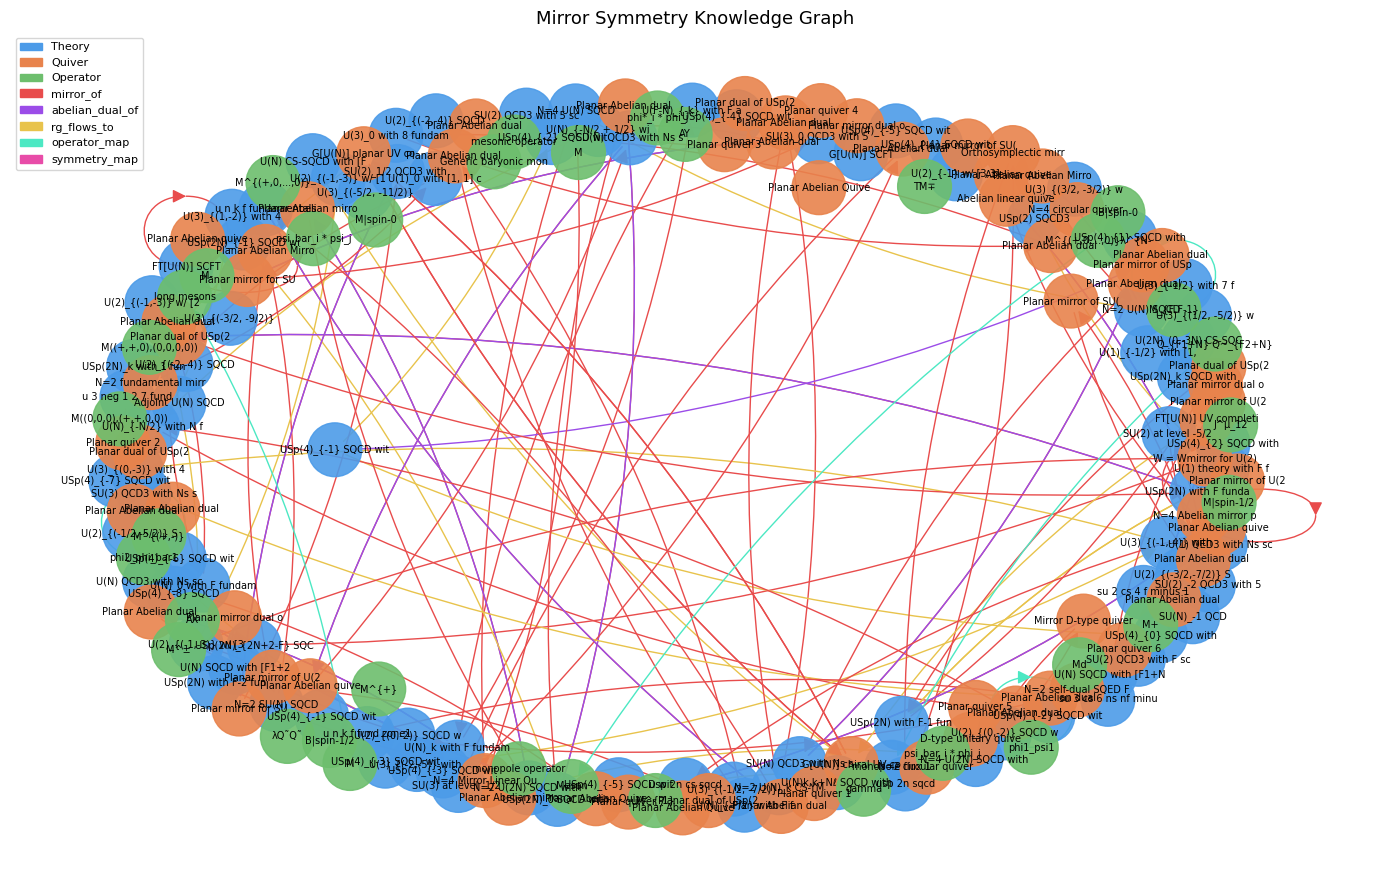

In [ ]:
import matplotlib.pyplot as plt

def visualise_graph(G: nx.MultiDiGraph, pos=None):
    plt.figure(figsize=(14, 9))

    if pos is None:
        pos = nx.spring_layout(G, seed=42, k=2)
    plt.figure(figsize=(14, 9))

    # Layout
    pos = nx.spring_layout(G, seed=42, k=2)

    # Color nodes by type
    color_map = {"Theory": "#4C9BE8", "Quiver": "#E8834C", "Operator": "#6DBE6D"}
    node_colors = [color_map.get(G.nodes[n].get("node_type", "?"), "grey") for n in G.nodes]

    # Color edges by type
    edge_color_map = {
        "mirror_of": "#E84C4C",
        "abelian_dual_of": "#9B4CE8",
        "rg_flows_to": "#E8C34C",
        "operator_map": "#4CE8C3",
        "symmetry_map": "#E84CA8",
    }
    edge_colors = [edge_color_map.get(d.get("edge_type", "?"), "grey")
                   for _, _, d in G.edges(data=True)]

    # Draw
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500, alpha=0.9)
    nx.draw_networkx_labels(G, pos,
                            labels={n: G.nodes[n].get("name", n)[:20] for n in G.nodes},
                            font_size=7)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors,
                           arrows=True, arrowsize=20,
                           connectionstyle="arc3,rad=0.1")

    # Legend
    from matplotlib.patches import Patch, FancyArrow
    node_legend = [Patch(color=c, label=t) for t, c in color_map.items()]
    edge_legend = [Patch(color=c, label=t) for t, c in edge_color_map.items()]
    plt.legend(handles=node_legend + edge_legend, loc="upper left", fontsize=8)

    plt.title("Mirror Symmetry Knowledge Graph", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
visualise_graph(G)

## **Multi-Hop Spot Check**

In [ ]:
# Query 1: mirror of USp(4)_{-1} with 7 fundamentals
r1 = multi_hop_query(G, "USp(4)_{-1} SQCD with 7",
                     ["abelian_dual_of"])
for r in r1:
    print(f"Answer: {r['answer_node']}")
    for hop in r['path']:
        print(f"  {hop['from']} --[{hop['edge']}]--> {hop['to']} (evidence: {hop['evidence']})")


print("---")

# Query 2: mirror of mass deformation of USp(4)_{-1} with 7 fundamentals
r2 = multi_hop_query(G, "USp(4)_{-1} SQCD with 7",
                     ["rg_flows_to"]
                     )
for r in r2:
    print(f"Answer: {r['answer_node']}")
    for hop in r['path']:
        print(f"  {hop['from']} --[{hop['edge']}]--> {hop['to']} (evidence: {hop['evidence']})")
print("---")

# Query 3: RG flow chain from U(3)_{0} with 8 fundamentals
r3 = multi_hop_query(G, "U(3)_0 with 8",
                     ["rg_flows_to"])
for r in r3:
    print(f"Answer: {r['answer_node']}")
    for hop in r['path']:
        print(f"  {hop['from']} --[{hop['edge']}]--> {hop['to']} (evidence: {hop['evidence']})")

Starting from: ['USp(4)_{-1} SQCD with 7 fundamentals']
Answer: Planar mirror of USp(4)_{-1} with 7 fundamentals
  USp(4)_{-1} SQCD with 7 fundamentals --[abelian_dual_of]--> Planar mirror of USp(4)_{-1} with 7 fundamentals (evidence: Equation 4.49)
---
Starting from: ['USp(4)_{-1} SQCD with 7 fundamentals']
Answer: USp(4)_{-2} SQCD with 6 fundamentals
  USp(4)_{-1} SQCD with 7 fundamentals --[rg_flows_to]--> USp(4)_{-2} SQCD with 6 fundamentals (evidence: Figure 4.10)
Answer: USp(4)_{0} SQCD with 6 fundamentals
  USp(4)_{-1} SQCD with 7 fundamentals --[rg_flows_to]--> USp(4)_{0} SQCD with 6 fundamentals (evidence: Figure 4.10)
---
Starting from: ['U(3)_0 with 8 fundamentals', 'Planar Abelian dual of U(3)_0 with 8 fundamentals']
Answer: U(3)_{-1/2} with 7 fundamentals
  U(3)_0 with 8 fundamentals --[rg_flows_to]--> U(3)_{-1/2} with 7 fundamentals (evidence: 3.57)


In [ ]:
save_graph(G)

import json
json_path = "/content/drive/MyDrive/graphrag_extractions_gemini/graph.json"
data = nx.node_link_data(G)
with open(json_path, "w") as f:
    json.dump(data, f, indent=2, default=str)
print("Saved")

Saved GraphML to /content/drive/MyDrive/graphrag_extractions/graph.graphml
Saved


Some further fixes

In [ ]:
# Find all cases where the same theory appears under different IDs
# by matching on (gauge_group, cs_level, fundamentals, supersymmetry)

def find_id_inconsistencies(processed):
    seen = {}  # key → list of ids

    for t in processed["theories"]:
        mc = t.get("matter_content") or {}
        key = (
            t.get("gauge_group", ""),
            str(t.get("cs_level", "")),
            str(mc.get("fundamentals", "")),
            str(t.get("supersymmetry", "")),
        )
        tid = t.get("id")
        if key not in seen:
            seen[key] = []
        seen[key].append(tid)

    dupes = {k: v for k, v in seen.items() if len(v) > 1}
    print(f"Theory groups with multiple IDs: {len(dupes)}")
    for key, ids in list(dupes.items())[:10]:
        print(f"  {key[0]} cs={key[1]} fund={key[2]}")
        for i in ids:
            print(f"    → {i}")

    return dupes

dupes = find_id_inconsistencies(processed)

Theory groups with multiple IDs: 1
  None cs= fund=
    → u_n_k_f_fundamentals
    → u_n_k_f_fund_zone1
    → u_3_neg_1_2_7_fund
    → usp_2n_sqcd
    → usp_2n_cs_sqcd
    → monopole_flux_1
    → su_2_cs_4_f_minus_1
    → su_3_cs_6_ns_nf_minus_1


In [ ]:
# Find all node pairs where normalised IDs match but actual IDs differ
def find_split_nodes(processed):
    def norm(s):
        return s.replace("_", "").lower() if s else ""

    all_theories = {t["id"]: t for t in processed["theories"]}
    all_quivers = {q["id"]: q for q in processed["quivers"]}
    all_nodes = {**all_theories, **all_quivers}

    norm_to_ids = {}
    for nid in all_nodes:
        n = norm(nid)
        norm_to_ids.setdefault(n, []).append(nid)

    splits = {k: v for k, v in norm_to_ids.items() if len(v) > 1}
    print(f"Split node pairs: {len(splits)}")
    for k, ids in splits.items():
        degrees = [G.degree(i) for i in ids]
        print(f"  norm='{k}'")
        for i, d in zip(ids, degrees):
            print(f"    {i} (degree={d})")

    return splits

splits = find_split_nodes(processed)

Split node pairs: 1
  norm='u3neg127fund'
    u3_neg1_2_7fund (degree=3)
    u_3_neg_1_2_7_fund (degree=[])


In [ ]:
r4 = multi_hop_query(G, "U(3)_0 with 8",
                     ["rg_flows_to", "rg_flows_to"])
for r in r4:
    print(f"Answer: {r['answer_node']}")
    for hop in r['path']:
        print(f"  {hop['from']} --[{hop['edge']}]--> {hop['to']}")

Starting from: ['U(3)_0 with 8 fundamentals', 'Planar Abelian dual of U(3)_0 with 8 fundamentals']
Dead end at step 2 — no 'rg_flows_to' edges from current nodes


# **Incorporating RAG**

In [ ]:
!pip install google-genai llama-index-embeddings-huggingface networkx pydantic

In [ ]:
import json, os, re, time
import networkx as nx
from google import genai
from google.colab import userdata
from pydantic import BaseModel, field_validator
from typing import Optional, Union
from llama_index.core import StorageContext, load_index_from_storage, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

In [ ]:
GEMINI_API_KEY = userdata.get('gemini_api_key')
client = genai.Client(api_key=GEMINI_API_KEY)

Settings.embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-large-en-v1.5")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
json_path = "/content/drive/MyDrive/graphrag_extractions_gemini/graph.json"
with open(json_path) as f:
    data = json.load(f)
G = nx.node_link_graph(data, directed=True, multigraph=True)
print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph loaded: 190 nodes, 126 edges


In [ ]:
storage_context = StorageContext.from_defaults(
    persist_dir="/content/drive/MyDrive/rag_hierarchy_index"
)
index = load_index_from_storage(storage_context)
base_retriever = index.as_retriever(similarity_top_k=6)
print("RAG index loaded")

RAG index loaded


In [ ]:
base_retriever = index.as_retriever(similarity_top_k=6)

# Test without AutoMerging
test_nodes = base_retriever.retrieve("USp(4) mirror symmetry")
print(f"Test retrieval: {len(test_nodes)} nodes")
print(f"First node: {test_nodes[0].text[:200]}")

Test retrieval: 6 nodes
First node: The passage describes the 3d mirror symmetry of USp(4)₋₂ gauge theory with 6 fundamental multiplets, obtained via a large mass limit X₁→+∞ that generates a divergent phase +iπX₁² matched by the S³ᵦ pa


In [ ]:
print("client:", type(client))
print("G nodes:", G.number_of_nodes())
print("base_retriever:", type(base_retriever))

# Test multi_hop_query exists
test = multi_hop_query(G, "USp(4)", ["abelian_dual_of"])
print("multi_hop_query works:", len(test), "results")

client: <class 'google.genai.client.Client'>
G nodes: 190
base_retriever: <class 'llama_index.core.indices.vector_store.retrievers.retriever.VectorIndexRetriever'>
Starting from: ['USp(4)_{-1} SQCD with 7 fundamentals', 'USp(4)_{0} SQCD with 6 fundamentals', 'USp(4)_{-2} SQCD with 6 fundamentals', 'USp(4)_{-3} SQCD with 5 fundamentals', 'USp(4)_{-1} SQCD with 5 fundamentals', 'USp(4)_{1} SQCD with 5 fundamentals', 'USp(4)_{-4} SQCD with 4 fundamentals', 'USp(4)_{-2} SQCD with 4 fundamentals', 'USp(4)_{2} SQCD with 4 fundamentals', 'USp(4)_{-5} SQCD with 3 fundamentals', 'USp(4)_{-3} SQCD with 3 fundamentals', 'USp(4)_{-6} SQCD with 2 fundamentals', 'USp(4)_{-4} SQCD with 2 fundamentals', 'USp(4)_{-7} SQCD with 1 fundamental', 'USp(4)_{-5} SQCD with 1 fundamental', 'USp(4)_{-8} SQCD', 'Planar mirror of USp(4)_{-1} with 7 fundamentals']
multi_hop_query works: 1 results


In [ ]:
# ── Intent classifier ─────────────────────────────────────────────────────────
INTENT_PROMPT = """Classify this physics query into exactly one category.
Return ONLY the category name, nothing else.

Categories:
- relational: asks about mirror pairs, RG flows, operator maps, s-confinement
  (e.g. "what is the mirror of X", "what does X flow to", "what maps to what")
- descriptive: asks for explanation, derivation, definition, physical interpretation
  (e.g. "explain X", "what is X", "how does X work", "what is the physical meaning")
- mixed: requires both a specific relationship AND explanation

Query: {query}"""

def classify_intent(query: str) -> str:
    response = client.models.generate_content(
        model='gemini-3.1-flash-lite',
        contents=INTENT_PROMPT.format(query=query),
        config={"max_output_tokens": 10, "temperature": 0.0}
    )
    intent = response.text.strip().lower()
    if intent not in ("relational", "descriptive", "mixed"):
        intent = "mixed"
    return intent

# ── RAG retriever ─────────────────────────────────────────────────────────────
def retrieve_from_rag(query: str, top_k: int = 4) -> list:
    nodes = base_retriever.retrieve(query)
    return [n.text for n in nodes[:top_k]]

# ── Synthesis ─────────────────────────────────────────────────────────────────
SYNTHESIS_PROMPT = """You are an expert in 3d N≤2 supersymmetric gauge theories answering questions about mirror symmetry from a PhD thesis by Anant Shri (SISSA, 2026).

You are given:
1. A query
2. Graph traversal results (structured relationships from knowledge graph)
3. Text passages from the thesis (for context and explanation)

Answer precisely. For relational questions, lead with the graph result. For explanations, use the text passages. Always cite evidence references when available.

QUERY: {query}

GRAPH CONTEXT:
{graph_context}

TEXT PASSAGES:
{text_context}

Answer:"""

def synthesise_hybrid(query: str, graph_results: list, rag_passages: list) -> str:
    if graph_results:
        graph_context = "\n".join([
            f"- {r['answer_node']} via: " +
            " → ".join(f"[{h['edge']}]" for h in r['path']) +
            f" (evidence: {r['path'][-1]['evidence'] if r['path'] else 'none'})"
            for r in graph_results
        ])
    else:
        graph_context = "No graph traversal results."

    text_context = "\n\n---\n\n".join(rag_passages) if rag_passages else "No text passages retrieved."

    response = client.models.generate_content(
        model='gemini-3.1-flash-lite',
        contents=SYNTHESIS_PROMPT.format(
            query=query,
            graph_context=graph_context,
            text_context=text_context,
        ),
        config={"max_output_tokens": 1024, "temperature": 0.0}
    )
    return response.text.strip()

# ── Master hybrid query ───────────────────────────────────────────────────────
def hybrid_query(query: str, edge_sequence: list = None) -> dict:
    intent = classify_intent(query)
    print(f"Intent: {intent}")

    graph_results = []
    if intent in ("relational", "mixed") and edge_sequence:
        graph_results = multi_hop_query(
            G, query, edge_sequence,
            start_node_type="Theory"
        )
        if not graph_results:
            graph_results = multi_hop_query(
                G, query, edge_sequence,
                start_node_type="Quiver"
            )

    rag_passages = retrieve_from_rag(query)

    answer = synthesise_hybrid(query, graph_results, rag_passages)

    return {
        "query": query,
        "intent": intent,
        "answer": answer,
        "graph_results": graph_results,
        "rag_passages": rag_passages,
    }

In [ ]:
# Relational
r1 = hybrid_query(
    "What is the mirror of USp(4)_{-1} with 7 fundamentals?"
)
print("Q1:", r1["answer"])
print()

# Descriptive
r2 = hybrid_query(
    "What is 3d mirror symmetry?",
)
print("Q2:", r2["answer"])
print()

# Mixed
r3 = hybrid_query(
    "What happens to the mirror of USp(4)_{-1} with 7 fundamentals under a mass deformation?"
)
print("Q3:", r3["answer"])

Intent: relational
Entity: USp(4)_{-1} with 7 fundamentals
Q1: Based on the provided text passages from the thesis, the mirror of $USp(4)_{-1}$ with 7 fundamental multiplets is identified as a **planar mirror dual** that functions as an **$\mathcal{N}=4$ descendant theory**.

According to the text, this theory serves as the starting point of an RG flow sequence. By applying $\pm m$ real mass deformations, the theory can be reduced from 7 fundamental multiplets down to 4 fundamental multiplets, passing through intermediate $USp(4)$ gauge theories with Chern-Simons levels ranging from $-4$ to $+2$.

Intent: descriptive
Entity: NONE
Q2: 3d mirror symmetry is an infrared duality that relates two distinct 3d $\mathcal{N} \le 2$ supersymmetric gauge theories by exchanging their topological and flavor symmetries. 

According to the provided text, this duality is characterized by the following features:

*   **Symmetry Exchange:** The duality maps topological symmetries of one theory to flavor

In [ ]:
def extract_entity(query: str) -> str:
    """Extract theory name from query for graph search."""
    response = client.models.generate_content(
        model='gemini-3.1-flash-lite',
        contents=f"""Extract the gauge theory name from this physics query.
Return ONLY the theory name as it would appear in a paper, e.g. "USp(4)_{{-1}} with 7 fundamentals".
If no specific theory is named return NONE.

Query: {query}""",
        config={"max_output_tokens": 30, "temperature": 0.0}
    )
    return response.text.strip()

def hybrid_query(query: str, edge_sequence: list = None) -> dict:
    intent = classify_intent(query)
    print(f"Intent: {intent}")

    # Extract entity separately for graph search
    entity = extract_entity(query)
    print(f"Entity: {entity}")

    graph_results = []
    if intent in ("relational", "mixed") and edge_sequence and entity != "NONE":
        graph_results = multi_hop_query(
            G, entity, edge_sequence,
            start_node_type="Theory"
        )
        if not graph_results:
            graph_results = multi_hop_query(
                G, entity, edge_sequence,
                start_node_type="Quiver"
            )

    rag_passages = retrieve_from_rag(query)
    answer = synthesise_hybrid(query, graph_results, rag_passages)

    return {
        "query": query,
        "intent": intent,
        "entity": entity,
        "answer": answer,
        "graph_results": graph_results,
        "rag_passages": rag_passages,
    }

In [ ]:
r4 = hybrid_query(
    "What is the S in class S?"
)
print("Q4:", r4["answer"])

Intent: descriptive
Entity: NONE
Q4: In the context of the thesis by Anant Shri, the "S" in **Class S** refers to the **six-dimensional $\mathcal{N}=(2,0)$ superconformal field theory (SCFT)**.

As described in the provided text, Class S theories are defined as four-dimensional $\mathcal{N}=2$ theories obtained by the compactification of these six-dimensional $\mathcal{N}=(2,0)$ SCFTs on a Riemann surface $C$ with a topological twist. The Seiberg-Witten curve of the resulting 4d theory is identified with this compactification surface $C$. Furthermore, the AGT correspondence relates the partition functions of these six-dimensional SCFTs when compactified on either a four-manifold $W_4$ or the Riemann surface $C_2$.
